In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

module_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import functions
import plot_config as pc

pc.apply_custom_mpl_settings()

<h1><span style="color:orange">Numerical Simulation Laboratory (NSL)</span></h1>

<h2><span style="color:green">Numerical Exercise 8</span></h2>

This notebook aims to apply the **Simulated Annealing (SA) optimization method** to a quantum mechanical problem. The goal is to obtain the **best approximation of the ground state (GS)** for a single particle in a one-dimensional space, subject to the external potential:

$$\mathcal{V}(x) = x^4 -\frac{5x^2}{2}.$$

The trial wavefunction proposed to parametrize the approximate ground state is defined as follows:

$$\Psi_{T}^{\mu, \sigma} \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}} + e^{-\frac{(x+\mu)^2}{2\sigma^2}}.$$

This optimization strategy relies on the **Variational Principle of Quantum Mechanics**. This principle states that the expectation value of the Hamiltonian $\hat{H}$, calculated using an arbitrary trial wavefunction $\Psi_T$ (provided it satisfies the necessary physical conditions, such as square-integrability), has as a lower bound the true ground state energy $E_0$:

$$\langle {\hat H} \rangle_T = \frac{\langle \Psi_T | {\hat H} | \Psi_T \rangle}{\langle \Psi_T | \Psi_T \rangle} \ge E_0 = \frac{\langle \Psi_0 | {\hat H} | \Psi_0 \rangle}{\langle \Psi_0 | \Psi_0 \rangle}.$$

Consequently, by minimizing this expectation value with respect to the variational parameters ($\mu$ and $\sigma$), we can identify the optimal parameter set that best approximates the ground state configuration.

Since the integral required to compute the Hamiltonian's expectation value is not analytically solvable for this specific model, we employ a numerical approach known as **Variational Monte Carlo (VMC)**.

The notebook is structured into three main sections:

1. [Implementation and simulation of the VMC](#vmc).

2. [SA implementation and GS parameters optimization](#sa)

3. [Estimation of the expectation value of the Hamiltonian](#h-mean-value) for the approximate GS, using the optimal parameters identified via SA.

<h2><span style="color:darkviolet">Variational Monte Carlo VMC</span></h2>

Frequently, the expectation value of the Hamiltonian for a specific wavefunction cannot be computed analytically, necessitating a numerical approach. These algorithms, which apply Monte Carlo methods to the study of quantum many-body systems, are collectively known as Quantum Monte Carlo methods.

The fundamental idea is to recast the analytic expression for the expectation value, typically written in Dirac notation, to define a probability density, specifically the squared modulus of the wavefunction, over which the average is computed. Since this probability density is generally complex and cannot be sampled efficiently using direct Monte Carlo techniques, the Metropolis-Hastings algorithm is employed. Consequently, we obtain:

$$\langle \hat{H} \rangle_T = 
\frac{\langle \Psi_T | \hat{H} | \Psi_T \rangle}{\langle \Psi_T | \Psi_T \rangle} = 
\frac{\int dx~\Psi^{\star}_T(x)~\hat{H}~\Psi_T(x)}{\int dx~\lvert \Psi_T(x) \rvert ^2} = 
\frac{\int dx~\Psi^{\star}_T(x)~\Psi_T(x)~\frac{\hat{H}~\Psi_T(x)}{\Psi_T(x)}}{\int dx~\lvert \Psi_T(x) \rvert ^2} =
\int dx~\frac{\lvert \Psi_T(x) \rvert^2}{\int dx~\lvert \Psi_T(x) \rvert ^2}~\frac{\hat{H}~\Psi_T(x)}{\Psi_T(x)} =
\int dx~p(x)~E_{loc}(x),$$

where $p(x)$ is the properly normalized probability density associated with the quantum state, and $E_{loc}(x)$ is the local energy. The latter can be computed analytically by applying the Hamiltonian operator $\hat{H} = -\frac{\hbar^2}{2m}\nabla^2 + \mathcal{V}(x)$ to the trial wavefunction $\Psi_T(x)$ and dividing the result by the wavefunction itself.

In our specific case, since the external potential operator is diagonal in the coordinate representation, its action on the wavefunction corresponds to simple multiplication, extracting the scalar potential:

$$\frac{\hat{\mathcal{V}}(x) \Psi_T(x)}{\Psi_T(x)} = \mathcal{V}(x).$$

Regarding the kinetic part, by setting $\hbar = 1$ and $m=1$, we obtain:

$$-\frac{1}{2}\frac{\partial^2}{\partial x^2} \Psi_T(x) = 
\ldots = 
\frac{1}{\sigma^2} \left( \frac{1}{2} - \frac{\frac{(x-\mu)^2}{2\sigma^2}e^{-\frac{(x-\mu)^2}{2\sigma^2}} + \frac{(x+\mu)^2}{2\sigma^2}e^{-\frac{(x+\mu)^2}{2\sigma^2}}}{e^{-\frac{(x-\mu)^2}{2\sigma^2}} + e^{-\frac{(x+\mu)^2}{2\sigma^2}}}\right).$$

Thus, the estimation of the Hamiltonian's expectation value is given by:

$$\langle \hat{H} \rangle_T \simeq 
\frac{1}{N} \sum_{i = 1}^{N}E_{loc}(x_i) \quad \quad \text{ with } x_i \sim p(x) = \frac{\lvert \Psi_T(x) \rvert^2}{\int dx~\lvert \Psi_T(x) \rvert^2}.$$


<a id="vmc"></a>

<h4>Implementation</h4>

Given that the fundamental structure of a Variational Monte Carlo (VMC) simulation closely parallels that of a canonical ensemble simulation, specifically the calculation of an observable's expectation value with respect to a specific probability distribution describing the system, I opted to utilize the library already developed for Exercises 4, 6, and 7. I extended the existing codebase by introducing a new simulation type and incorporating the necessary components to address the specific requirements of the VMC algorithm.

The simulation models a system characterized by a single degree of freedom. Its position evolves via a one-dimensional random walk, utilizing uniform displacements centered on the current position with an amplitude of `_delta`. Since the transition probability is symmetric (uniform and centered on the previous position), the Metropolis acceptance probability is defined as the minimum between 1 and the ratio of the squared modulus of the trial wavefunction calculated for the proposed configuration versus the current one. Once a proposed move is accepted or rejected, the quantity of interest is evaluated and accumulated for the block averaging method, after which a new move is proposed.

To implement this system, I modified several methods within the `System` class:

- **Input Parameters**: I appended new properties to the input file, which are processed by the `initialize()` method:
    - `SIMULATION_TYPE = 4`: Designates that the system should perform a VMC simulation.
    - `NPARAM`: A line containing multiple values; the first specifies the number of parameters defining the trial wavefunction, while the subsequent values define the parameters themselves (in this specific case, we have two parameters, $\mu$ and $\sigma$).

- **Initialization Routine**: I updated the `initialize()` method to read these new inputs and set the corresponding private variables of the class:
    ```cpp
        void System :: initialize(){
            // ... //
            else if(_sim_type == 4) coutf << "VARIATIONAL MONTE CARLO (VMC) SIMULATION" << endl;
            // ... //
            else if( property == "NPARAM"){
                input >> _nparam;
                coutf << "NPARAM= " << _nparam << "       ";
                _parameters.set_size(_nparam);
                _parameters.zeros();
                for(int i{}; i < _nparam; i++){
                input >> _parameters(i);
                coutf << "PARAM(" << i <<")=" << _parameters(i) << "       ";
                }
                coutf << endl;
                _parameters_current.set_size(_nparam);
                _parameters_current.zeros();
            }
            // ... // 
        }
    ```

- **Configuration File**: I modified the positional configuration file `config.xyz`, read by the `read_configuration()` method, to represent a single particle in a one-dimensional space:
    ```text
        1
        #Comment!
        VMC  -0.900000    0.000000    0.000000
    ```

- Measurement Flags: I introduced a flag, `_measure_loc_energy`, which is set to true when the `LOCAL_ENERGY` property is read from the `properties.dat` file, along with its corresponding index `_index_loc_energy` within the `_measurement` vector. This logic is handled within the `initialize_properties()` method, following the workflow of the existing implementation.

- **Metropolis-Hastings Algorithm**: I implemented the Metropolis-Hastings step routine, designing it to be as generic as possible to allow for future applications to multi-particle systems in three-dimensional space (to be totally generic we should define both velocity and force $N_{dim} X N_{part}$ or $N_{part} X N_{dim}$ matrix):
    ```cpp
        void System :: step(){ 
            // ... //
            else{
                for(int i=0; i<_npart; i++){
                    this->move(i);
                }
            }
            // ... //
        }
    ```
    ```cpp
        void System :: move(int i){
            // ... //
            else if(_sim_type == 4){
                vec shift(_ndim);
                shift(0) = _rnd.Rannyu(-1.0,1.0) * _delta;
                shift(1) = 0.0;
                shift(2) = 0.0;
                _particle(i).translate(shift);
                if(this->metro(i)){
                    _particle(i).acceptmove();
                    _naccepted++;
                } else _particle(i).moveback();
            }
            return;
        }
    ```
    ```cpp
        bool System :: metro(int i){
            bool decision = false;
            double delta_E, acceptance;
            // ... //
            else if (_sim_type == 4){
                acceptance = this->Psi2(i,true)/this->Psi2(i, false);
                if(_rnd.Rannyu(0.0,1.0) < acceptance){
                    decision = true;
                }
            }
            return decision;
        }
    ```

- **Wavefunction Evaluation**: I added a dedicated function to calculate the squared modulus of the trial wavefunction:
    ```cpp
        double System :: Psi2(int i, bool xnew){
            double a{_particle(i).getposition(0, xnew) - _parameters(0)};
            double b{_particle(i).getposition(0, xnew) + _parameters(0)};
            double c{0.5/(_parameters(1) * _parameters(1))};
            double d{(-1.0)*a*a*c};
            double f{(-1.0)*b*b*c};
            double e_1{exp(d)};
            double e_2{exp(f)};
            double psi{e_1 + e_2};
            return psi*psi;
        }
    ```

- **Local Energy Measurement**: I incorporated the local energy calculation routine into the `measure()` method, implementing the derived analytical formulas:
    ```cpp
        void System :: measure(){
            // ... //
            if (_measure_loc_energy){
                double x = _particle(0).getposition(0, true);
                double x1 = x - _parameters(0);
                double x2 = x + _parameters(0);
                double d = 1.0/(_parameters(1)*_parameters(1));
                double y1 = 0.5 * d * x1 * x1;
                double y2 = 0.5 * d * x2 * x2;
                double e1 = exp((-1.0)*y1);
                double e2 = exp((-1-0)*y2);
                double h_loc = d * (0.5 - (y1*e1 + y2*e2)/(e1+e2));
                double v = x*x*x*x - 2.5*x*x;
                _measurement(_index_loc_energy) = h_loc + v;
            } // ... //
        }

- **Data Averaging**: I updated the `averages()` method to handle the block averaging, as well as the progressive mean and uncertainty for the local energy:
    ```cpp
        void System :: averages(int blk){
            // ... //
            if(_measure_loc_energy){
                average  = _average(_index_loc_energy);
                sum_average = _global_av(_index_loc_energy);
                sum_ave2 = _global_av2(_index_loc_energy);
                if(_print_vmc){
                    coutf.open("../OUTPUT/hamiltonian.dat",ios::app);
                    coutf << setw(12) << blk
                          << setw(20) << average
                          << setw(20) << sum_average/double(blk)
                          << setw(20) << this->error(sum_average, sum_ave2, blk) << endl;
                    coutf.close();
                }
            }
        }
    ```

**NB**: To be fully generalizable to $n$-particle systems in $N$ dimensions, the code should utilize $(N_{dim} \times N_{part})$ or $(N_{part} \times N_{dim})$ matrices. Furthermore, it should incorporate a C++ automatic differentiation library (e.g., AUTODIFF) to enable the computation of the Laplacian operator $\nabla^2$ independently of the specific trial ground state wavefunction used.

<h4>Simulation</h4>

To evaluate the performance of the implemented code, I performed three distinct simulations initialized with different walker positions. The primary objective was to analyze the equilibration time of the Metropolis algorithm—specifically, how rapidly it begins to correctly sample the target distribution $p(x)$ as a function of the starting coordinate. Consequently, I conducted three simulations of 5000 steps each, recording the Metropolis acceptance rate, the instantaneous local energy, and the walker's position at every step.

The simulations were performed using the following input parameters:

<div align="center">

| Parameters | SIMULATION 1 | SIMULATION 2 | SIMULATION 3 |
| :--- | :--- | :--- | :--- |
| SIMULATION_TYPE | 4 | 4 | 4 |
| RESTART | 0 | 0 | 0 |
| NPART | 1 | 1 | 1 |
| X0 | 10.0 | -0.30 | -0.80 |
| R_CUT | 2.5 | 2.5 | 2.5 |
| DELTA | 2.65 | 2.65 | 2.65 |
| NBLOCKS | 5000 | 5000 | 5000 |
| NSTEPS | 1 | 1 | 1 |
| NPARAM | 2 0.8 0.6 | 2 0.8 0.6 | 2 0.8 0.6 |

</div>

In [2]:
pos1 = np.loadtxt("equilibration/scenario1/OUTPUT/walker.dat", usecols=(0), unpack=True)
pos2 = np.loadtxt("equilibration/scenario2/OUTPUT/walker.dat", usecols=(0), unpack=True)
pos3 = np.loadtxt("equilibration/scenario3/OUTPUT/walker.dat", usecols=(0), unpack=True)

step, acceptance1 = np.loadtxt("equilibration/scenario1/OUTPUT/acceptance.dat", usecols=(0,1), unpack=True)
acceptance2 = np.loadtxt("equilibration/scenario2/OUTPUT/acceptance.dat", usecols=(1))
acceptance3 = np.loadtxt("equilibration/scenario3/OUTPUT/acceptance.dat", usecols=(1))
h1, H1 = np.loadtxt("equilibration/scenario1/OUTPUT/hamiltonian.dat", usecols=(1,2), unpack=True)
h2, H2 = np.loadtxt("equilibration/scenario2/OUTPUT/hamiltonian.dat", usecols=(1,2), unpack=True)
h3, H3 = np.loadtxt("equilibration/scenario3/OUTPUT/hamiltonian.dat", usecols=(1,2), unpack=True)

xmin = min(step) - 100
xmax = max(step) + 100
acf_step = len(step)

mu, sigma = functions.leggi_nparam_da_input("equilibration/scenario1/INPUT/input.dat")

walker_start1 = np.loadtxt("equilibration/scenario1/INPUT/CONFIG/config.xyz", skiprows=2, usecols=(1))
walker_start2 = np.loadtxt("equilibration/scenario2/INPUT/CONFIG/config.xyz", skiprows=2, usecols=(1))
walker_start3 = np.loadtxt("equilibration/scenario3/INPUT/CONFIG/config.xyz", skiprows=2, usecols=(1))

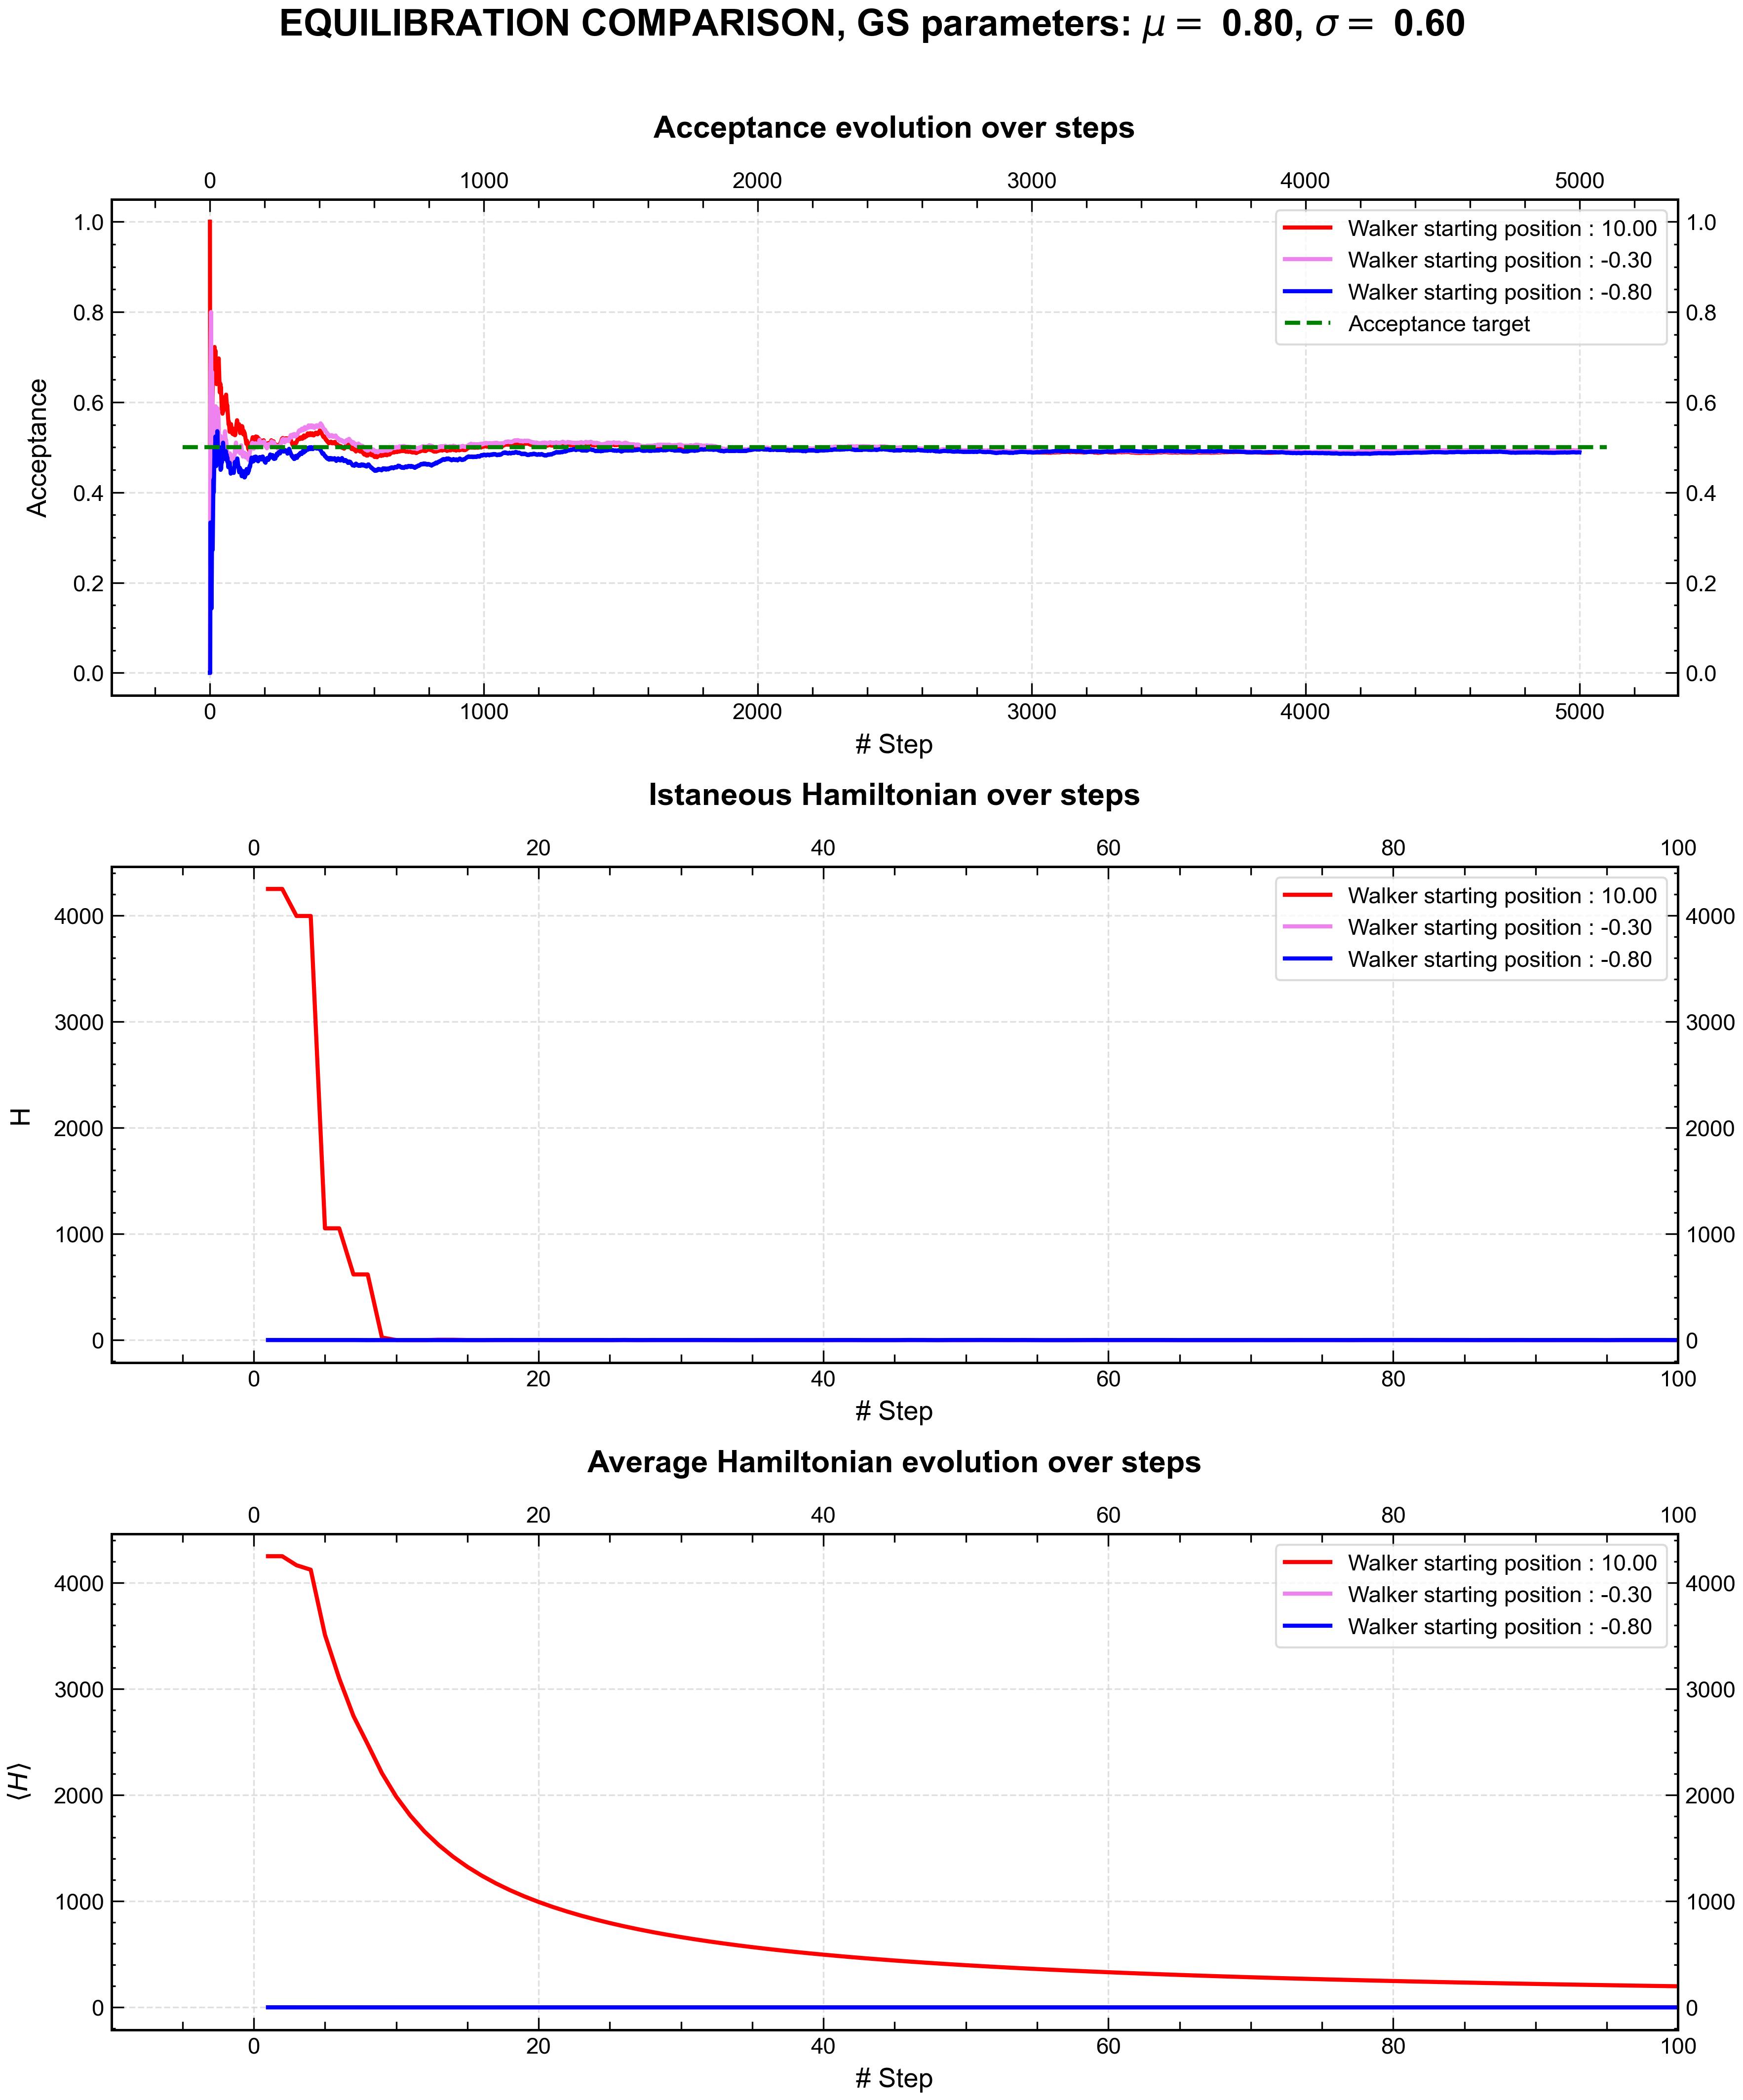

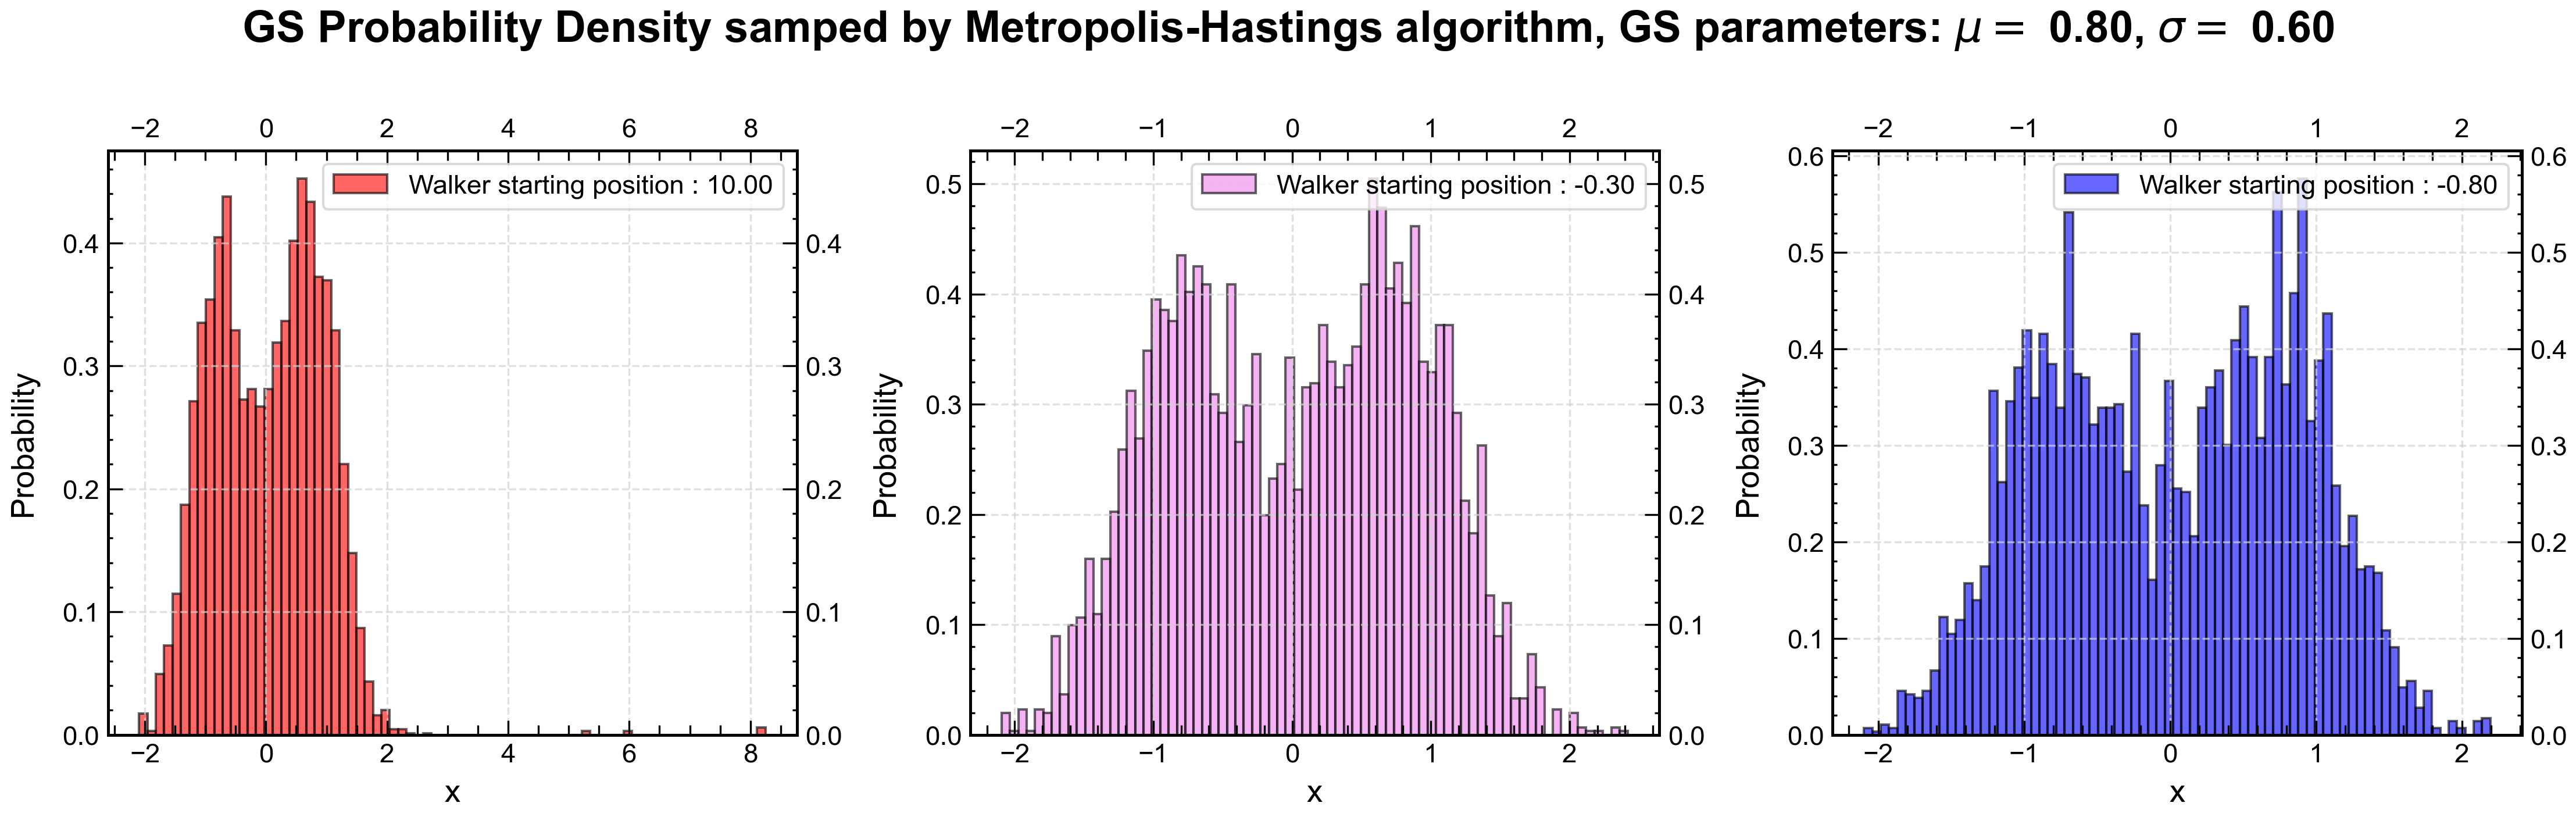

In [3]:
fig, axs = plt.subplots(3,1,figsize=(12,15))

plt.suptitle(rf"EQUILIBRATION COMPARISON, GS parameters: $\mu = $ {mu:.2f}, $\sigma =$ {sigma:.2f}", fontsize=18, fontweight='bold')

axs[0].set_title("Acceptance evolution over steps", pad=30)
axs[0].plot(step, acceptance1, color='red', label=f'Walker starting position : {walker_start1:.2f}')
axs[0].plot(step, acceptance2, color='violet', label=f'Walker starting position : {walker_start2:.2f}')
axs[0].plot(step, acceptance3, color='blue', label=f'Walker starting position : {walker_start3:.2f}')
axs[0].set_xlabel('# Step', labelpad=5)
axs[0].set_ylabel('Acceptance', labelpad=10)
axs[0].hlines(0.5, xmin, xmax, color='green', linestyle='--', label='Acceptance target')
axs[0].legend()

axs[1].set_title("Istaneous Hamiltonian over steps", pad=30)
axs[1].plot(step, h1, color='red', label=f'Walker starting position : {walker_start1:.2f}')
axs[1].plot(step, h2, color='violet', label=f'Walker starting position : {walker_start2:.2f}')
axs[1].plot(step, h3, color='blue', label=f'Walker starting position : {walker_start3:.2f}')
axs[1].set_xlabel('# Step', labelpad=5)
axs[1].set_ylabel('H', labelpad=10)
axs[1].set_xlim(-10, 100)
axs[1].legend()

axs[2].set_title("Average Hamiltonian evolution over steps", pad=30)
axs[2].plot(step, H1, color='red', label=f'Walker starting position : {walker_start1:.2f}')
axs[2].plot(step, H2, color='violet', label=f'Walker starting position : {walker_start2:.2f}')
axs[2].plot(step, H3, color='blue', label=f'Walker starting position : {walker_start3:.2f}')
axs[2].set_xlabel('# Step', labelpad=5)
axs[2].set_ylabel(r'$\langle H \rangle$', labelpad=10)
axs[2].set_xlim(-10, 100)
axs[2].legend()

fig.tight_layout(rect=[0, 0.03, 1, 0.97])
fig.savefig("plot/equilibration/equilibration_compare.png")

fig, axs = plt.subplots(1,3,figsize=(15,5))

plt.suptitle(rf"GS Probability Density samped by Metropolis-Hastings algorithm, GS parameters: $\mu = $ {mu:.2f}, $\sigma =$ {sigma:.2f}", fontsize=18, fontweight='bold')

axs[0].hist(pos1, bins=75, color='red', alpha=0.6, density=True, edgecolor='black', label=f'Walker starting position : {walker_start1:.2f}')
axs[0].set_xlabel('x', labelpad=5)
axs[0].set_ylabel('Probability', labelpad=10)
axs[0].legend()
axs[1].hist(pos2, bins=75, color='violet', alpha=0.6, density=True, edgecolor='black', label=f'Walker starting position : {walker_start2:.2f}')
axs[1].set_xlabel('x', labelpad=5)
axs[1].set_ylabel('Probability', labelpad=10)
axs[1].legend()
axs[2].hist(pos3, bins=75, color='blue', alpha=0.6, density=True, edgecolor='black', label=f'Walker starting position : {walker_start3:.2f}')
axs[2].set_xlabel('x', labelpad=5)
axs[2].set_ylabel('Probability', labelpad=10)
axs[2].legend()

fig.tight_layout(rect=[0, 0.03, 1, 0.97])
fig.savefig("plot/equilibration/equil_gs_compare.png")

plt.show()

<h4>Conclusions</h4>

We observe that by setting the Metropolis step width to $\Delta = 2.65$, regardless of the initial walker position, the MCMC sampling of the trial wavefunction squared modulus $|\Psi_T(x)|^2$ reaches a stable acceptance rate of $50\%$ after approximately 2000 steps. This rate falls within the optimal range typically required by the Metropolis-Hastings algorithm

A closer inspection of the instantaneous local energy trajectory reveals that, even when initializing the walker far from the target probability density, the system begins sampling energy values compatible with the target distribution within 10–20 Monte Carlo steps. These values align with those observed in simulations initialized within the high-probability region. This behavior is further evidenced by the three histograms displaying the probability density sampled by the Metropolis algorithm. Even when starting from a position distant from regions of non-negligible density, the algorithm quickly converges to the correct sampling distribution (indicated by the low normalized count of outliers corresponding to the initial transient phase).

However, **a crucial consideration addresses the bias introduced by initialization**. When starting from a highly anomalous position distant from the correct sampling regions, the instantaneous local energy can differ from the expected value by a factor of $10^4$. Consequently, the cumulative mean of the Hamiltonian is heavily biased by these initial outliers sampled in regions of vanishingly small probability. For this reason, a slower convergence of the mean value toward the true expectation value is observed. Therefore, **it is strongly recommended to initialize the algorithm** such that the walker starts at a position consistent with the target probability density (or to discard the initial equilibration steps).

In [4]:
step, h = np.loadtxt("ac_simulation/OUTPUT/hamiltonian.dat", usecols=(0,1), unpack=True)
# Minimum block size
L_min = 1
# Maximum block size
L_max = 5000
# Array of tested block sizes
L_values = np.arange(L_min, L_max + 1)
# Number of block sizes attempted
num_L = len(L_values)
# Arrays for calculated errors corresponding to successive block sizes
err = np.zeros(num_L)

# Loop over the tested block sizes and fill the respective error arrays
for i in range(num_L):
    L = L_values[i]
    err[i] = functions.data_blocking(h, L)

In [5]:
acf_step = 10000
step = step[:acf_step]
h = h[:acf_step]
var = np.var(h)
acf = functions.unbiased_acf(h, var)

NVE Correlation time from unbiased sample ACF : τ ≈ 3.19 steps


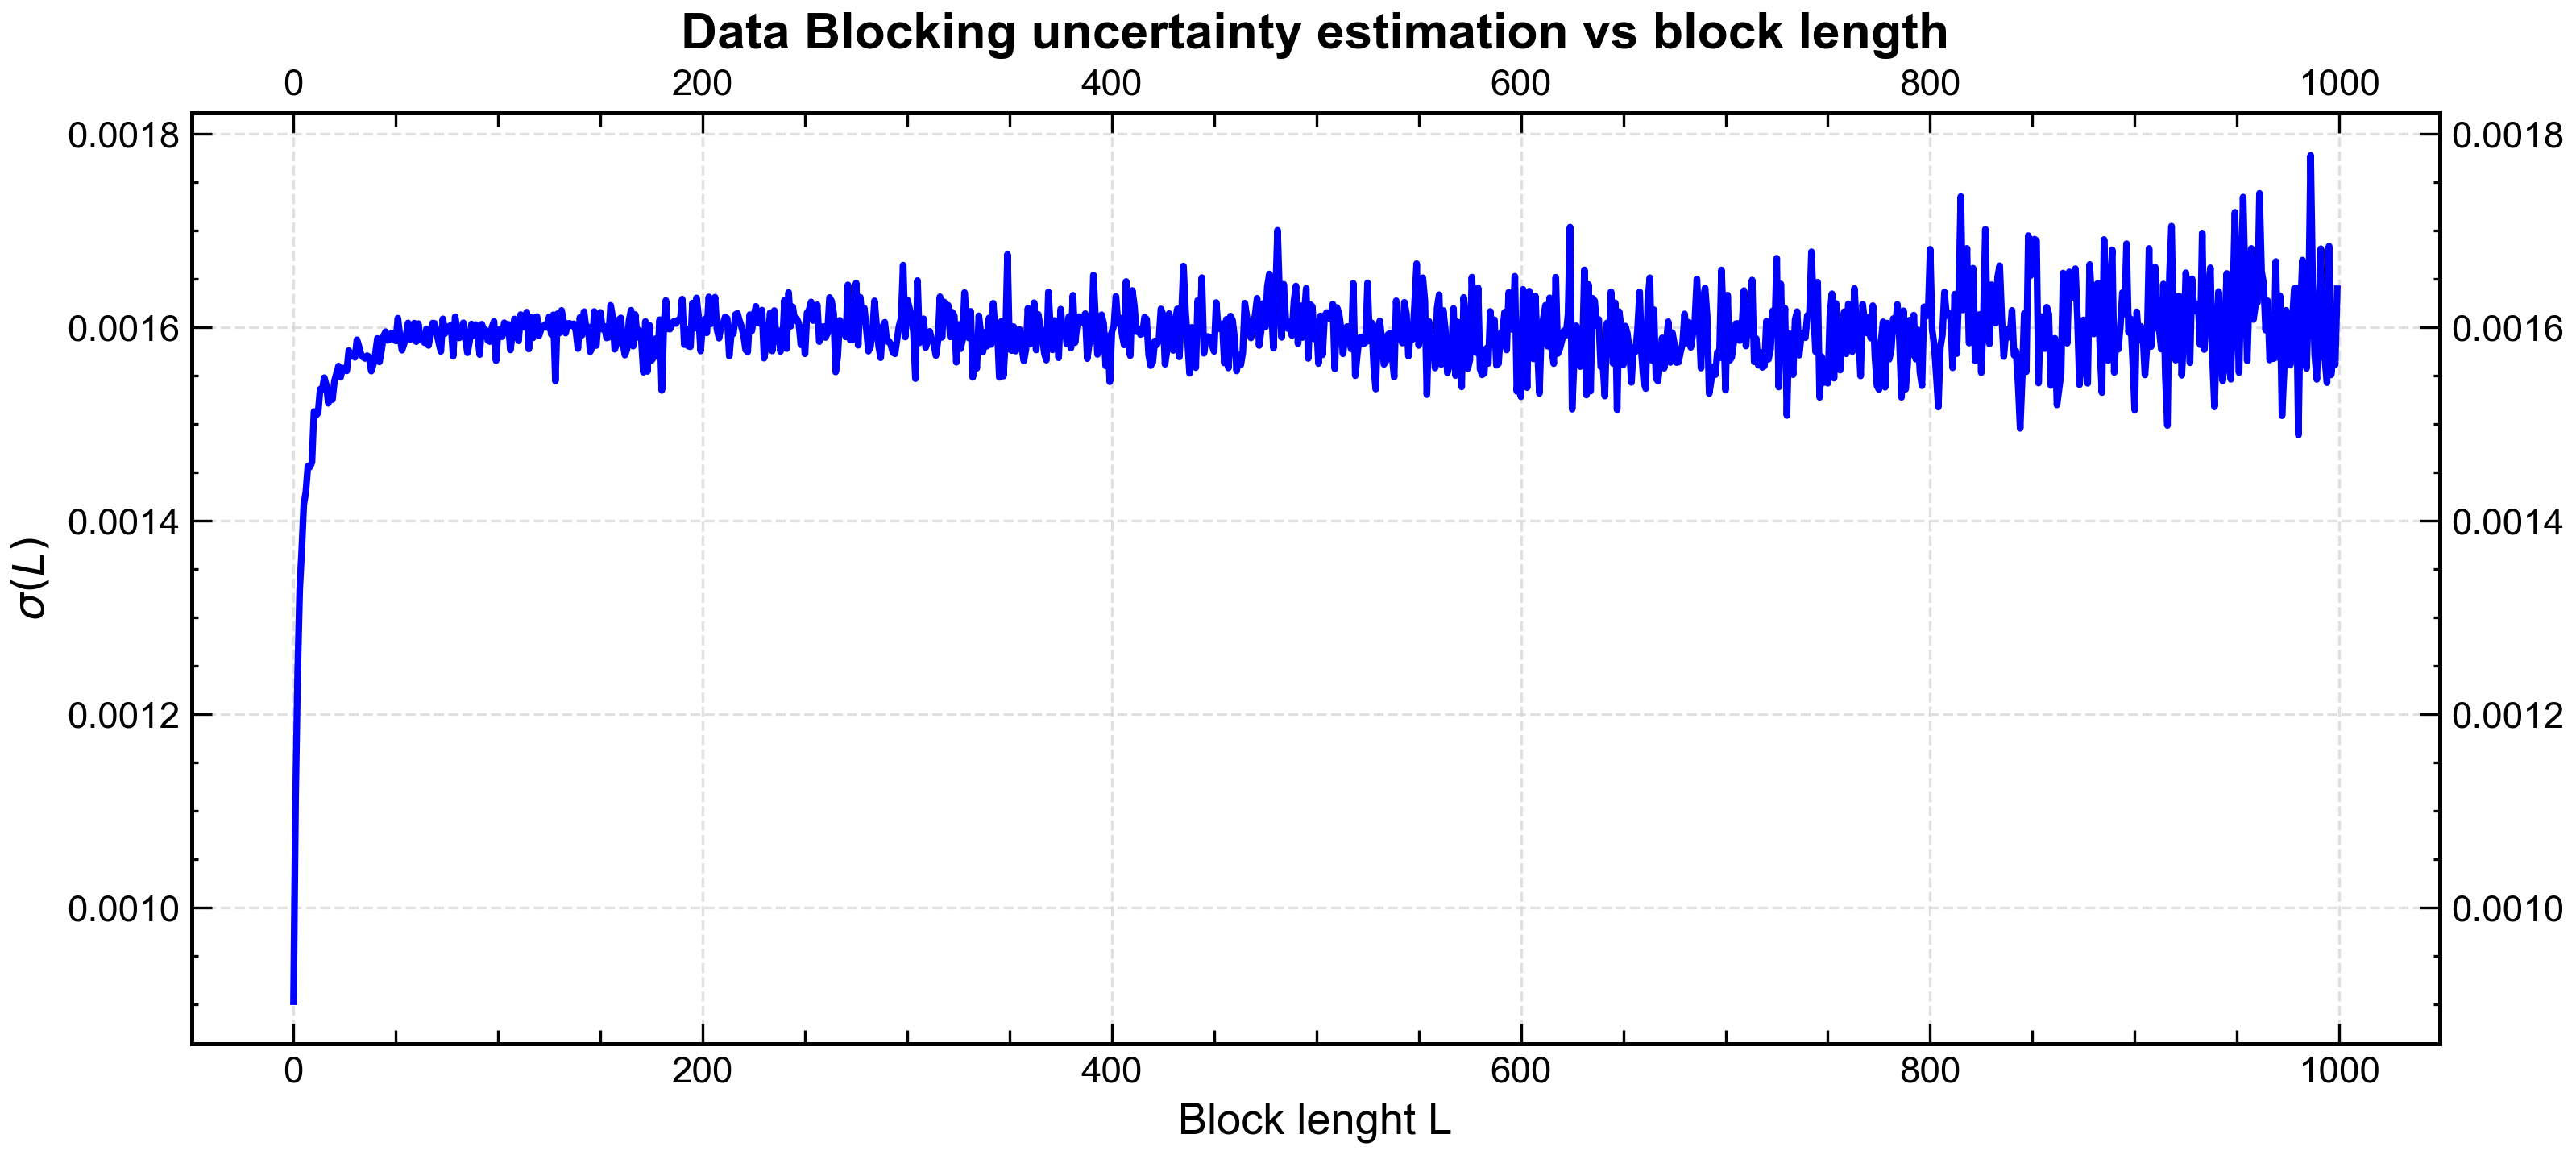

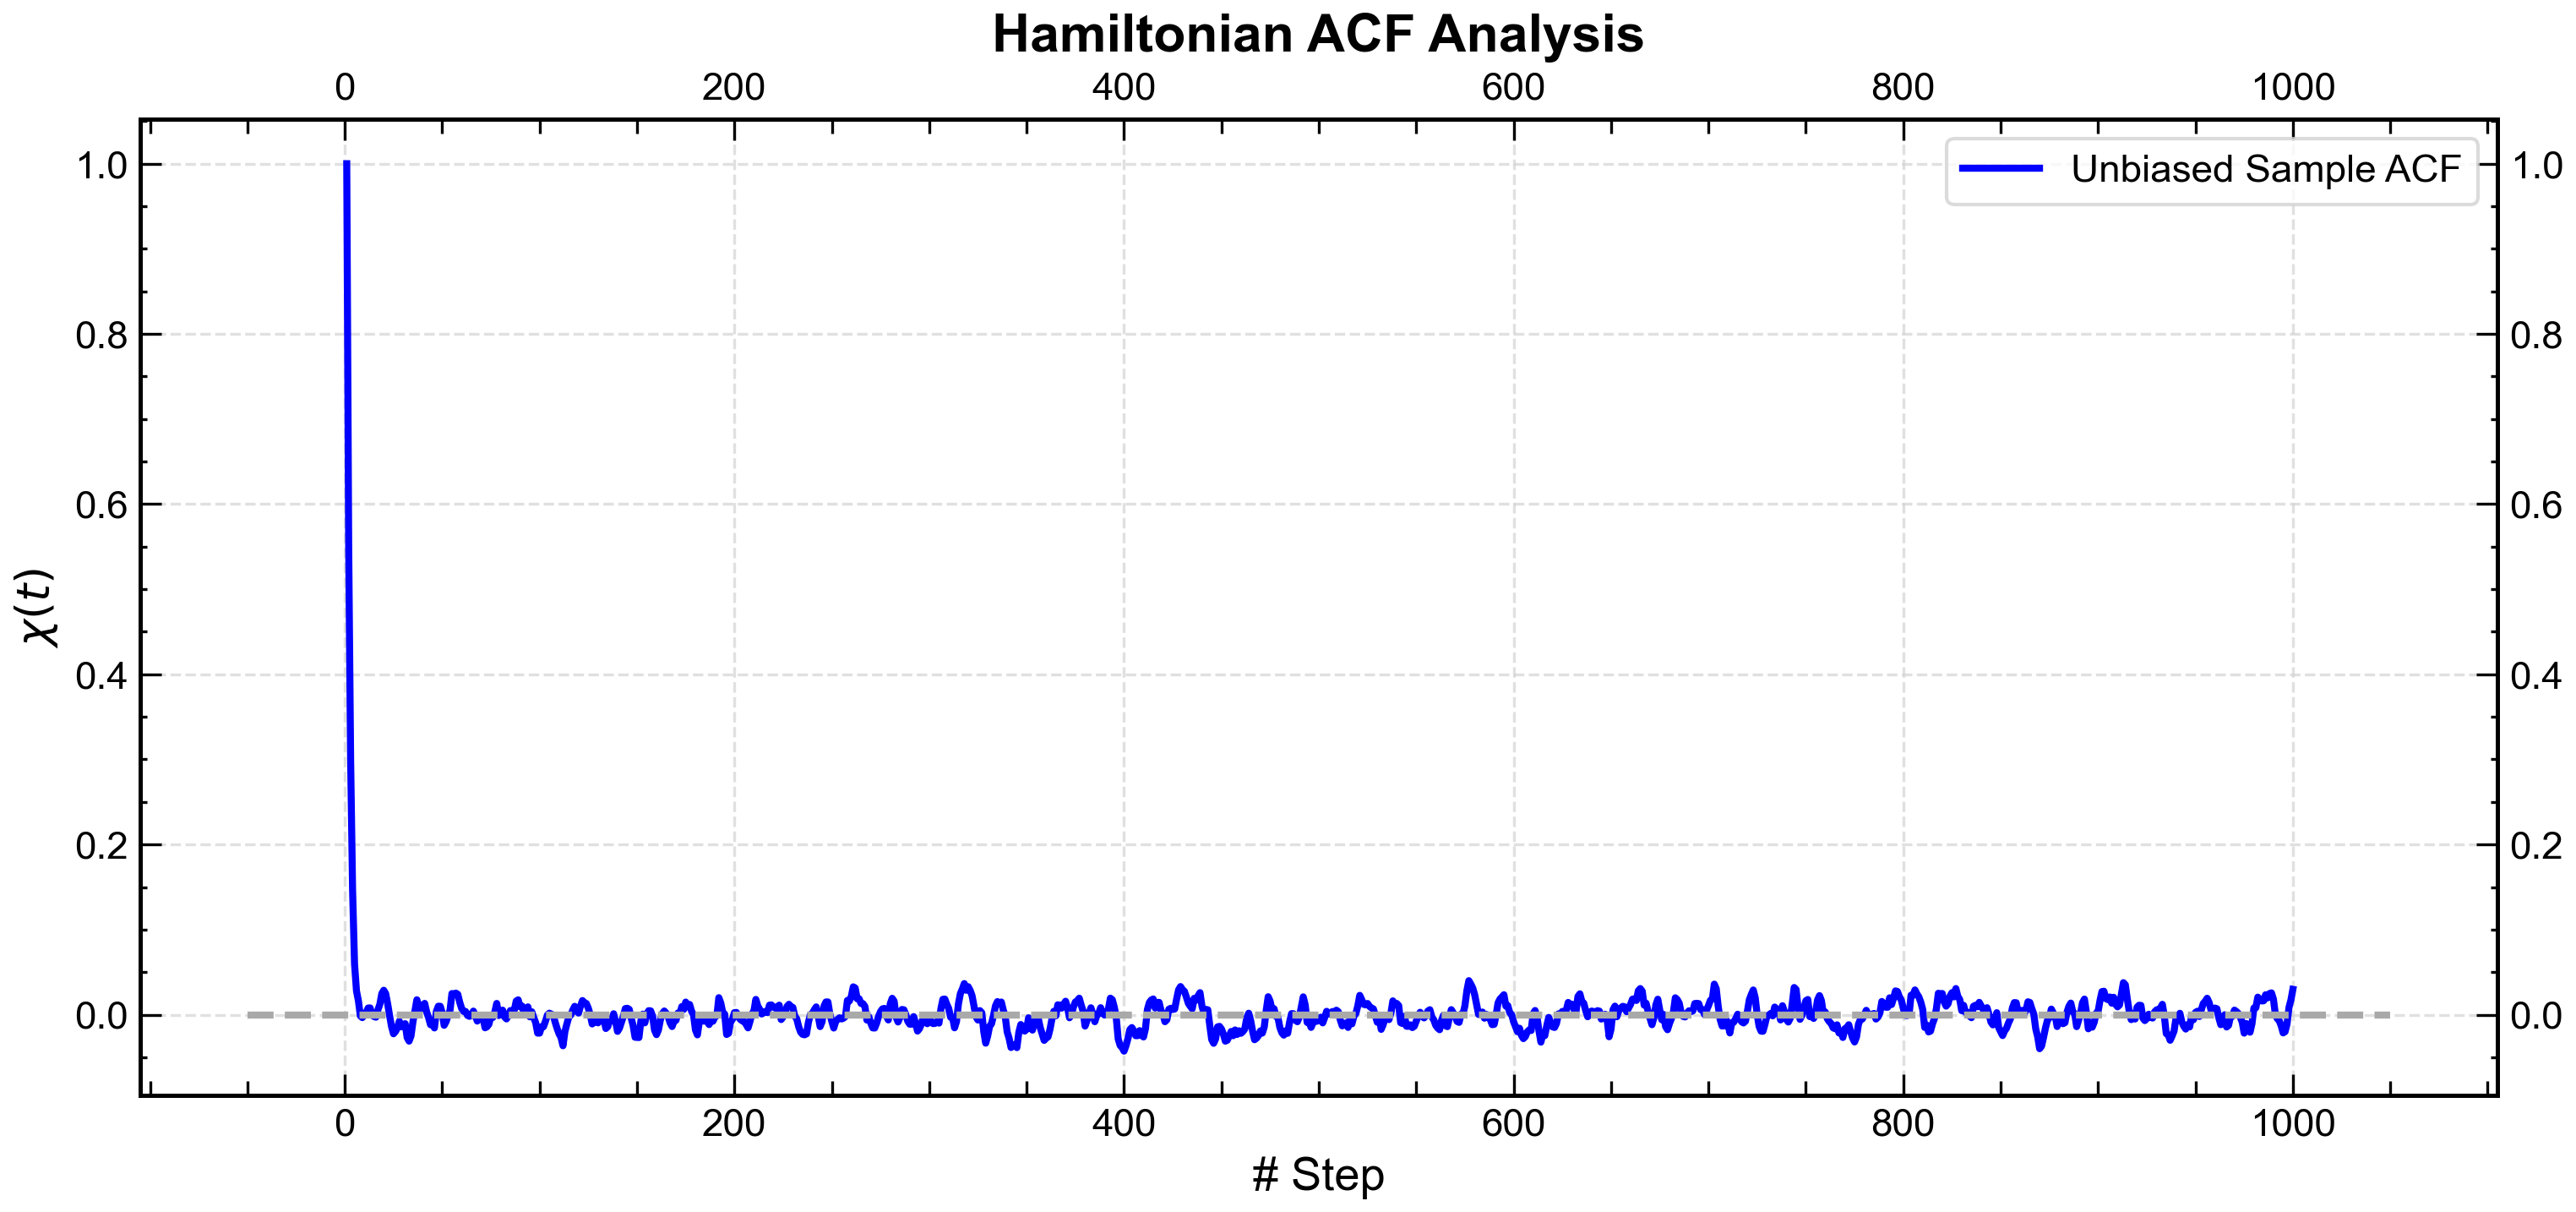

In [6]:
err = err[:1000]
x = np.arange(0, len(err))

fig = plt.figure(figsize=(12,5))

plt.title("Data Blocking uncertainty estimation vs block length")
plt.plot(x, err, color="blue")
plt.xlabel("Block lenght L")
# plt.xlim(-10,200)
# plt.xlim(-10,1000)
plt.ylabel(r"$\sigma (L)$")
fig.savefig("plot/equilibration/block_size.png")

fig = plt.figure(figsize=(12, 5)) 

plt.title("Hamiltonian ACF Analysis")
plt.plot(step[:1000], acf[:1000], color="blue", label="Unbiased Sample ACF")
plt.xlabel("# Step")
plt.ylabel(r"$\chi(t)$")
plt.hlines(0, -50, 1050, color="darkgrey", linestyle="--")
plt.legend()
fig.savefig("plot/equilibration/autocorrelation.png")

ct = functions.integrated_ac_time(acf)

print(f"NVE Correlation time from unbiased sample ACF : τ ≈ {ct:.2f} steps")

plt.show()

<h4>Conclusions</h4>

By examining the autocorrelation function (ACF) associated with the local energy, calculated at every Metropolis step, we observe that successive configurations sampled by the algorithm rapidly decorrelate from one another. The ACF drops effectively to zero after only three Metropolis moves, after which it exhibits only random noise caused by the stochastic fluctuations of the energy value.

Associated with the ACF study, we performed an analysis of the estimated error associated with the mean local energy, plotted as a function of the block size used in the block averaging method.

We observe that for block sizes smaller than approximately $50$ steps, the uncertainty estimate underestimates the true value. This systematic underestimation occurs because the sampled energy values at different timesteps are still statistically correlated, violating the assumption of independent and identically distributed (i.i.d.) data required for accurate error estimation.

As the block size increases to approximately $200–400$ steps, the estimated error saturates at a constant value. This saturation point indicates that the block size has become significantly larger than the correlation time of the sampling process, confirming that the average energy within each block can now be treated as an independent statistical variable. To ensure the statistical validity of the uncertainty associated with the mean local energy, we chose a final block size of $1000$ steps.

<h2><span style="color:darkviolet">Optimization</span></h2>

The term **optimization** encompasses a broad class of problems, both physical and abstract, where mathematical techniques are applied to identify the optimal solution for a specific request. In the context of physics, these problems generally fall into two main branches:

1. **Data-driven optimization** (**Regression/Fitting**): The objective is to determine the model parameters that best describe a real-world dataset (e.g., finding the parameters that minimize the residuals between a theoretical model and experimental data).

2. **Theoretical optimization**: Problems with a strong theoretical connotation, such as the application of variational principles (e.g., the Principle of Least Action), which provide an alternative pathway to derive the equations of motion or the ground state of a system.

Formally, an optimization problem can be defined as follows. Consider a parameter vector $\mathbf{x} = (x_1, \ldots, x_n)$ defined within a domain $S \subseteq X^n$, where the space $X$ may be either discrete or continuous. The primary goal is to identify the vector $\mathbf{x}^*$ that:

- Minimizes an objective function (or **loss/cost function**), denoted as $L(\mathbf{x})$. In multi-objective problems ($I > 1$), one seeks to minimize a set of functions $L_1(\mathbf{x}), \ldots, L_I(\mathbf{x})$.

- Satisfies $J$ **equality** constraints $h_j(\mathbf{x}) = 0$ and $K$ **inequality** constraints $g_k(\mathbf{x}) \leq 0$.

A critical challenge in optimization arises from the nature of the objective function $L(\mathbf{x})$. In many physical applications, $L(\mathbf{x})$ is highly **non-linear**, **multi-modal** (possessing many local minima), or **non-differentiable**. Furthermore, in computational physics contexts like Monte Carlo simulations, the cost function is often **stochastic**, meaning that its value is estimated with statistical noise rather than computed exactly. In such scenarios, information regarding gradients ($\nabla L$) is either unavailable or computationally expensive to estimate reliably. Consequently, we rely on specialized algorithms capable of optimizing "black-box" functions without requiring derivatives.

Optimization algorithms are typically classified based on their search strategies:

- **Gradient-based** vs. **Derivative-free**.

- **Deterministic** vs. **Stochastic**.

- **Global Search** vs. **Local Search**.

<div style="text-align: center;">
<img src="images/opt_alg_class.jpg" alt="OPT algorithms classification" width="600">
</div>

A fundamental trade-off in optimization is the balance between local refinement and global exploration. The parameter space of complex physical systems is often rugged, making the identification of the true global minimum ($\mathbf{x}_{global}$) extremely difficult. Often, computational and temporal constraints force us to accept a "good enough" local minimum. Moreover, when minimizing a quantity subject to stochastic fluctuations (like the energy in VMC), searching for a minimum with precision higher than the intrinsic statistical noise becomes physically meaningless.

A powerful class of algorithms designed to tackle these challenges is **Metaheuristics**. Often nature-inspired, these algorithms orchestrate an interaction between two fundamental strategies:

1. **Exploitation** (**Intensification**): Focusing the search in regions where a promising solution has already been found to refine it.

2. **Exploration** (**Diversification**): Generating widely distributed, independent trajectories to probe the parameter space globally and avoid getting trapped in local basins.


<a id="sa"></a>

<h3><span style="color:darkviolet">Simulated Annealing SA</span></h3>

**Simulated Annealing** (**SA**) is a stochastic metaheuristic algorithm specifically designed for global optimization problems where finding a good approximation of the global minimum is more critical than finding a precise local minimum.

The method draws an analogy from the physical process of **annealing** in metallurgy. In annealing, a material is heated and then cooled slowly to alter its physical properties.

- **Fast cooling** (**Quenching**): The system does not have time to reconfigure into equilibrium; it gets "frozen" in a **metastable** state with higher internal energy (a local minimum).

- **Slow cooling**: The system maintains thermal equilibrium at each step, allowing atoms to arrange themselves into a crystalline lattice corresponding to the minimum energy state (Ground State).

In the algorithmic counterpart, the objective function $L(\mathbf{x})$ plays the role of **"energy"**, and a control parameter $T$ plays the role of **temperature**. The core idea is to sample, through Metropolis-Hastings algorithm, configurations according to the Boltzmann distribution $p(\mathbf{x}) \propto \exp(-L(\mathbf{x})/T)$.

- **High Temperature** ($T \to \infty$): The system accepts almost any move, even those that increase the cost function ($L_{new} > L_{old}$). This promotes vigorous **exploration** of the global space.

- **Low Temperature** ($T \to 0$): The probability of accepting "bad" moves vanishes. The system settles into a minimum, shifting the focus to **exploitation**.

Common cooling laws include:

- **Linear Schedule**: $T_{k+1} = T_k - \eta$. This is simple but requires careful tuning of the decrement $\eta$ to avoid cooling too fast at low temperatures.

- **Geometric Schedule** (Exponential): $T_{k+1} = \alpha T_k$, where $\alpha \in [0.8, 0.99]$. This is the most widely used approach in practice as it offers a good compromise between speed and exploration capability, spending more time at lower temperatures where settling into the minimum is crucial.

Starting from an initial parameter configuration $\mathbf{x}$, a new candidate configuration $\mathbf{x}'$ is proposed. The proposal mechanism itself is crucial: ideally, the magnitude of the perturbation (the parameter **step size**) should be related to the temperature. At high $T$, large steps allow the algorithm to traverse the entire search space (Exploration), while at low $T$, smaller steps facilitate precise convergence (Exploitation).

The candidate is accepted or rejected based on the Metropolis-Hastings criterion:

$$P(\text{accept } \mathbf{x} \to \mathbf{x}') = \min \left( 1, e^{-\beta \Delta L} \right)$$

where $\Delta L = L(\mathbf{x}') - L(\mathbf{x})$. If $\Delta L < 0$ (the move improves the solution), it is always accepted. If $\Delta L > 0$ (the move worsens the solution), it is accepted with probability $e^{-\beta \Delta L}$.

In this notebook, we employ Simulated Annealing to optimize the variational parameters $\mu$ and $\sigma$ of a trial wave function. Our objective function is the expectation value of the energy, $\langle E \rangle_{\Psi_{\mu, \sigma}}$.

The procedure operates as follows:

- **Initialization**: Fix an initial temperature $T$ and parameter set $(\mu, \sigma)$.
- **Energy Estimation**: Use an internal VMC routine to estimate the mean energy $\langle E \rangle$ for the current parameters.
- **Perturbation**: Propose a new set $(\mu', \sigma')$ by sampling a random displacement.
- **Evaluation**: Estimate the energy for the new configuration.
- **Decision**: Accept or reject the new parameters based on the Metropolis acceptance probability.
- **Cooling**: After a fixed number of steps, reduce the temperature according to the geometric schedule and repeat using the current best parameters.

By gradually lowering the temperature, the algorithm navigates the noisy energy landscape, avoiding local traps and converging towards the set of parameters that minimizes the variational energy.


<h4>Implementation</h4>

The Simulated Annealing algorithm was integrated into the `System` class by introducing several key modifications and methods designed to orchestrate the optimization process.

1. **Input Parameters and Initialization**: The input configuration was expanded to include specific control parameters for the annealing schedule. The initialize() method now reads:
    - `DELTA_TEMP`: Defines the cooling rate. In this implementation, a geometric cooling schedule is adopted ($T_{k+1} = \text{DELTA\_TEMP} \times T_k$).
    - `NTEMP`: The total number of temperature steps in the schedule.
    - `SA_TEMP_STEPS`: The number of Monte Carlo steps (parameter perturbations) performed at each fixed temperature.
    - `DELTA_PARAM`: Controls the maximum size of the random displacement for the variational parameters ($\mu, \sigma$).
    - `EQUIL_STEPS`: The number of equilibration steps performed by the VMC walker after each parameter update before starting the energy measurement. This is statistically crucial to dissipate the bias from the previous configuration and ensure the walker samples the new $|\Psi_T|^2$ distribution correctly.

2. **Streamlining Output**: To optimize performance and avoid I/O bottlenecks during the extensive SA runs, boolean flags (`NO_PRINT_VMC` & `NO_PRINT_ACC`) were introduced to suppress the detailed block-by-block output typical of a standard VMC run, retaining only the relevant optimization data.

3. **The VMC Engine** (`vmc()` method): A dedicated method was implemented to execute the Variational Monte Carlo integration for a fixed set of parameters. This method:
    1. Performs equilibration steps to adjust the walker to the current wavefunction parameters.
    2. Executes the measurement loop to estimate the expectation value of the Hamiltonian $\langle H \rangle$.
    3. Stores the final mean energy (`_final_h`), its statistical error, and the last position of the walker. Retaining the walker's position allows the next iteration to start from a physically plausible configuration rather than a random state, accelerating convergence.
    ```cpp
        void System :: vmc(){

            double h = 0.0;
            double h2 = 0.0;
            double err = 0.0;
            double last_walk_pos = 0.0;

            for(int i{}; i < _eq_steps; i++){
                step();
            }
            
            _block_av.zeros();
            _average.zeros();
            _global_av.zeros();
            _global_av2.zeros();

            for(int i{}; i < _nblocks; i++){
                for(int j{}; j < _nsteps; j++){
                step();
                measure();
                }
                averages(i+1);
                block_reset(i+1);
            }

            h =  _global_av(_index_loc_energy)/_nblocks;
            h2 =  _global_av2(_index_loc_energy)/_nblocks;
            err = this->error(h, h2, _nblocks);
            last_walk_pos = _particle(0).getposition(0, true);

            _final_h = h;
            _final_err = err;
            _final_x = last_walk_pos; 

            return;

        }
    ```

4. **The Metropolis Step in Parameter Space** (`SA_fixed_temp_step()` method): This method performs the core logic of the annealing at a fixed temperature $T$. It iterates `_nsteps_SA` times, and for each step:
    1. **Perturbation**: A new configuration is proposed by adding a uniform random displacement to the current parameters.
    2. **Constraint**: A "hard-wall" constraint is applied to $\sigma$ (_parameters(1)_) to ensure it remains positive ($> 10^{-6}$), preserving physical consistency.
    3. **Evaluation**: The `vmc()` method is called to estimate the energy of the new configuration ($E_{new}$).
    4. **Selection**: The move is accepted or rejected based on the Boltzmann factor of the energy difference $\Delta E = E_{new} - E_{old}$. If accepted, the "best" estimates are updated; otherwise, the system retains the previous state.
    ```cpp
        void System :: SA_fixed_temp_step(){

            _naccepted_SA = 0;
            
            vmc();
            double h_current = _final_h;
            double err_current = _final_err;
            double x_current = _final_x;
            _parameters_current = _parameters;

            for(int i{}; i < _nsteps_SA; i++){
                // print_data_step(i);
                for(int l{}; l < _nparam; l++){
                _parameters(l) = _parameters_current(l) + _rnd.Rannyu(-1.0, 1.0)*_delta_parameters(l);
                if(_parameters(1) <= 1e-6) _parameters(1) = 1e-6;
                }

                _particle(0).setposition(0, x_current);
                vmc();

                double h_trial = _final_h;
                double err_trial = _final_err;
                double x_trial = _final_x;

                double delta_h = h_trial - h_current;
                double acceptance = exp((-1.0)*_beta*delta_h);
                if(_rnd.Rannyu(0.0, 1.0) < acceptance){
                _h_best = h_trial;
                _err_best = err_trial;
                x_current = x_trial;
                _x_best = x_trial;
                _parameters_current = _parameters;
                _naccepted_SA++;
                }else{
                    _h_best = h_current;
                    _err_best = err_current;
                    _x_best = x_current;
                }
            }
            // print_data_step(_nsteps_SA);

        }
    ```    


5. **The Annealing Schedule** (`SA()` method): The master method `SA()` orchestrates the full simulation. It initializes the data headers, iterates through the temperature schedule, invokes the single-temperature routine, and applies the geometric cooling law (`_temp *= _delta_temp`) after each stage.
    ```cpp
        void System :: SA(){
            header_data();
            for(int i{}; i < _n_temp; i++){
                SA_fixed_temp_step();
                print_data();
                _temp *= _delta_temp;
                _beta = 1.0/_temp;
            }
            finalize();
        }
    ```

6. **Data Logging**: Specialized output routines were implemented to generate analysis-ready data files:
    - `header_data()` and `print_data()` manage the creation of `data.dat`, logging the temperature, current $\mu$ and $\sigma$, mean energy with error, and the acceptance rate for each temperature step.
    - An auxiliary method `print_data_step()` was also designed to log instantaneous moves within a single temperature step (useful for debugging or fine-grained trajectory analysis), though it is primarily disabled in production runs to save disk space.


<h4>Simulation</h4>

To investigate the optimization behavior as a function of the input parameters, we performed 12 **distinct Simulated Annealing runs**. All simulations utilized the **same cooling schedule** but **varied** the **initial parameter configuration** and the **Metropolis step size** (perturbation size) for the parameters $\mu$ and $\sigma$.

The SA simulations were conducted using the following input parameters:

<div align="center">

| PARAMETERS | SIMULATION 1 | SIMULATION 2 | SIMULATION 3 | SIMULATION 4 | SIMULATION 5 | SIMULATION 6 | SIMULATION 7 | SIMULATION 8 | SIMULATION 9 | SIMULATION 10 | SIMULATION 11 | SIMULATION 12 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| SIMULATION_TYPE | 4 | 4 | 4 | 4 | 4 | 4 | 4 | 4 | 4 | 4 | 4 | 4 |
| RESTART | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| TEMP | 1.5 | 1.5 | 1.5 | 1.5 | 1.5 | 1.5 | 1.5 | 1.5 | 1.5 | 1.5 | 1.5 | 1.5 |
| DELTA_TEMP | 0.95 | 0.95 | 0.95 | 0.95 | 0.95 | 0.95 | 0.95 | 0.95 | 0.95 | 0.95 | 0.95 | 0.95 |
| NTEMP | 250 | 250 | 250 | 250 | 250 | 250 | 250 | 250 | 250 | 250 | 250 | 250 |
| SA_TEMP_STEPS | 75 | 75 | 75 | 75 | 75 | 75 | 75 | 75 | 75 | 75 | 75 | 75 |
| EQUIL_STEPS | 500 | 500 | 500 | 500 | 500 | 500 | 500 | 500 | 500 | 500 | 500 | 500 |
| NPART | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |
| DELTA | 2.65 | 2.65 | 2.65 | 2.65 | 2.65 | 2.65 | 2.65 | 2.65 | 2.65 | 2.65 | 2.65 | 2.65 |
| NBLOCKS | 50 | 50 | 50 | 50 | 50 | 50 | 50 | 50 | 50 | 50 | 50 | 50 |
| NSTEPS | 1000 | 1000 | 1000 | 1000 | 1000 | 1000 | 1000 | 1000 | 1000 | 1000 | 1000 | 1000 |
| NPARAM | 2 0.5 0.6 | 2 0.5 0.6 | 2 0.5 0.6 | 2 0.5 0.6 | 2 0.5 0.6 | 2 -1.5 0.6 | 2 -1.5 0.6 | 2 -1.5 0.6 | 2 -1.5 0.6 | 2 -1.5 0.6 | 2 4.5 2.0 | 2 4.5 2.0 |
| DELTA_PARAM | 0.1 0.1 | 0.1 0.01 | 0.1 0.005 | 0.01 0.01 | 0.01 0.005 | 0.1 0.1 | 0.1 0.01 | 0.1 0.005 | 0.01 0.01 | 0.01 0.005 | 0.01 0.005 | 0.1 0.1 |

</div>

From these simulations, we visualized both the **mean Hamiltonian** value $\langle H \rangle$ and its **uncertainty** as a function of the inverse temperature ($\beta$) and the **trajectory** followed by the algorithm in the parameter space ($\mu, \sigma$).

-------------------------------------------------------------------------------------------------------------------------
 Run | T_min_idx | Beta_min_idx |    H_min | Err_H_min | Mu_min | Sigma_min |
-------------------------------------------------------------------------------------------------------------------------
   1 |  0.001906 |        524.6 | -0.44955 |   0.00892 |  0.811 |     0.629 |
   2 |  0.000053 |      19019.0 | -0.45203 |   0.00896 |  0.868 |     0.618 |
   3 |  0.000033 |      30176.9 | -0.45105 |   0.00894 | -0.783 |     0.628 |
   4 |  0.000005 |     211923.2 | -0.45008 |   0.00892 |  0.775 |     0.597 |
   5 |  0.000022 |      45487.0 | -0.45450 |   0.00901 |  0.826 |     0.630 |
   6 |  0.000108 |       9275.1 | -0.44956 |   0.00891 | -0.779 |     0.617 |
   7 |  0.000108 |       9275.1 | -0.44848 |   0.00889 |  0.770 |     0.638 |
   8 |  0.000013 |      75971.7 | -0.44958 |   0.00891 |  0.792 |     0.624 |
   9 |  0.000017 |      58785.1 | -0.45063 |   0.00893

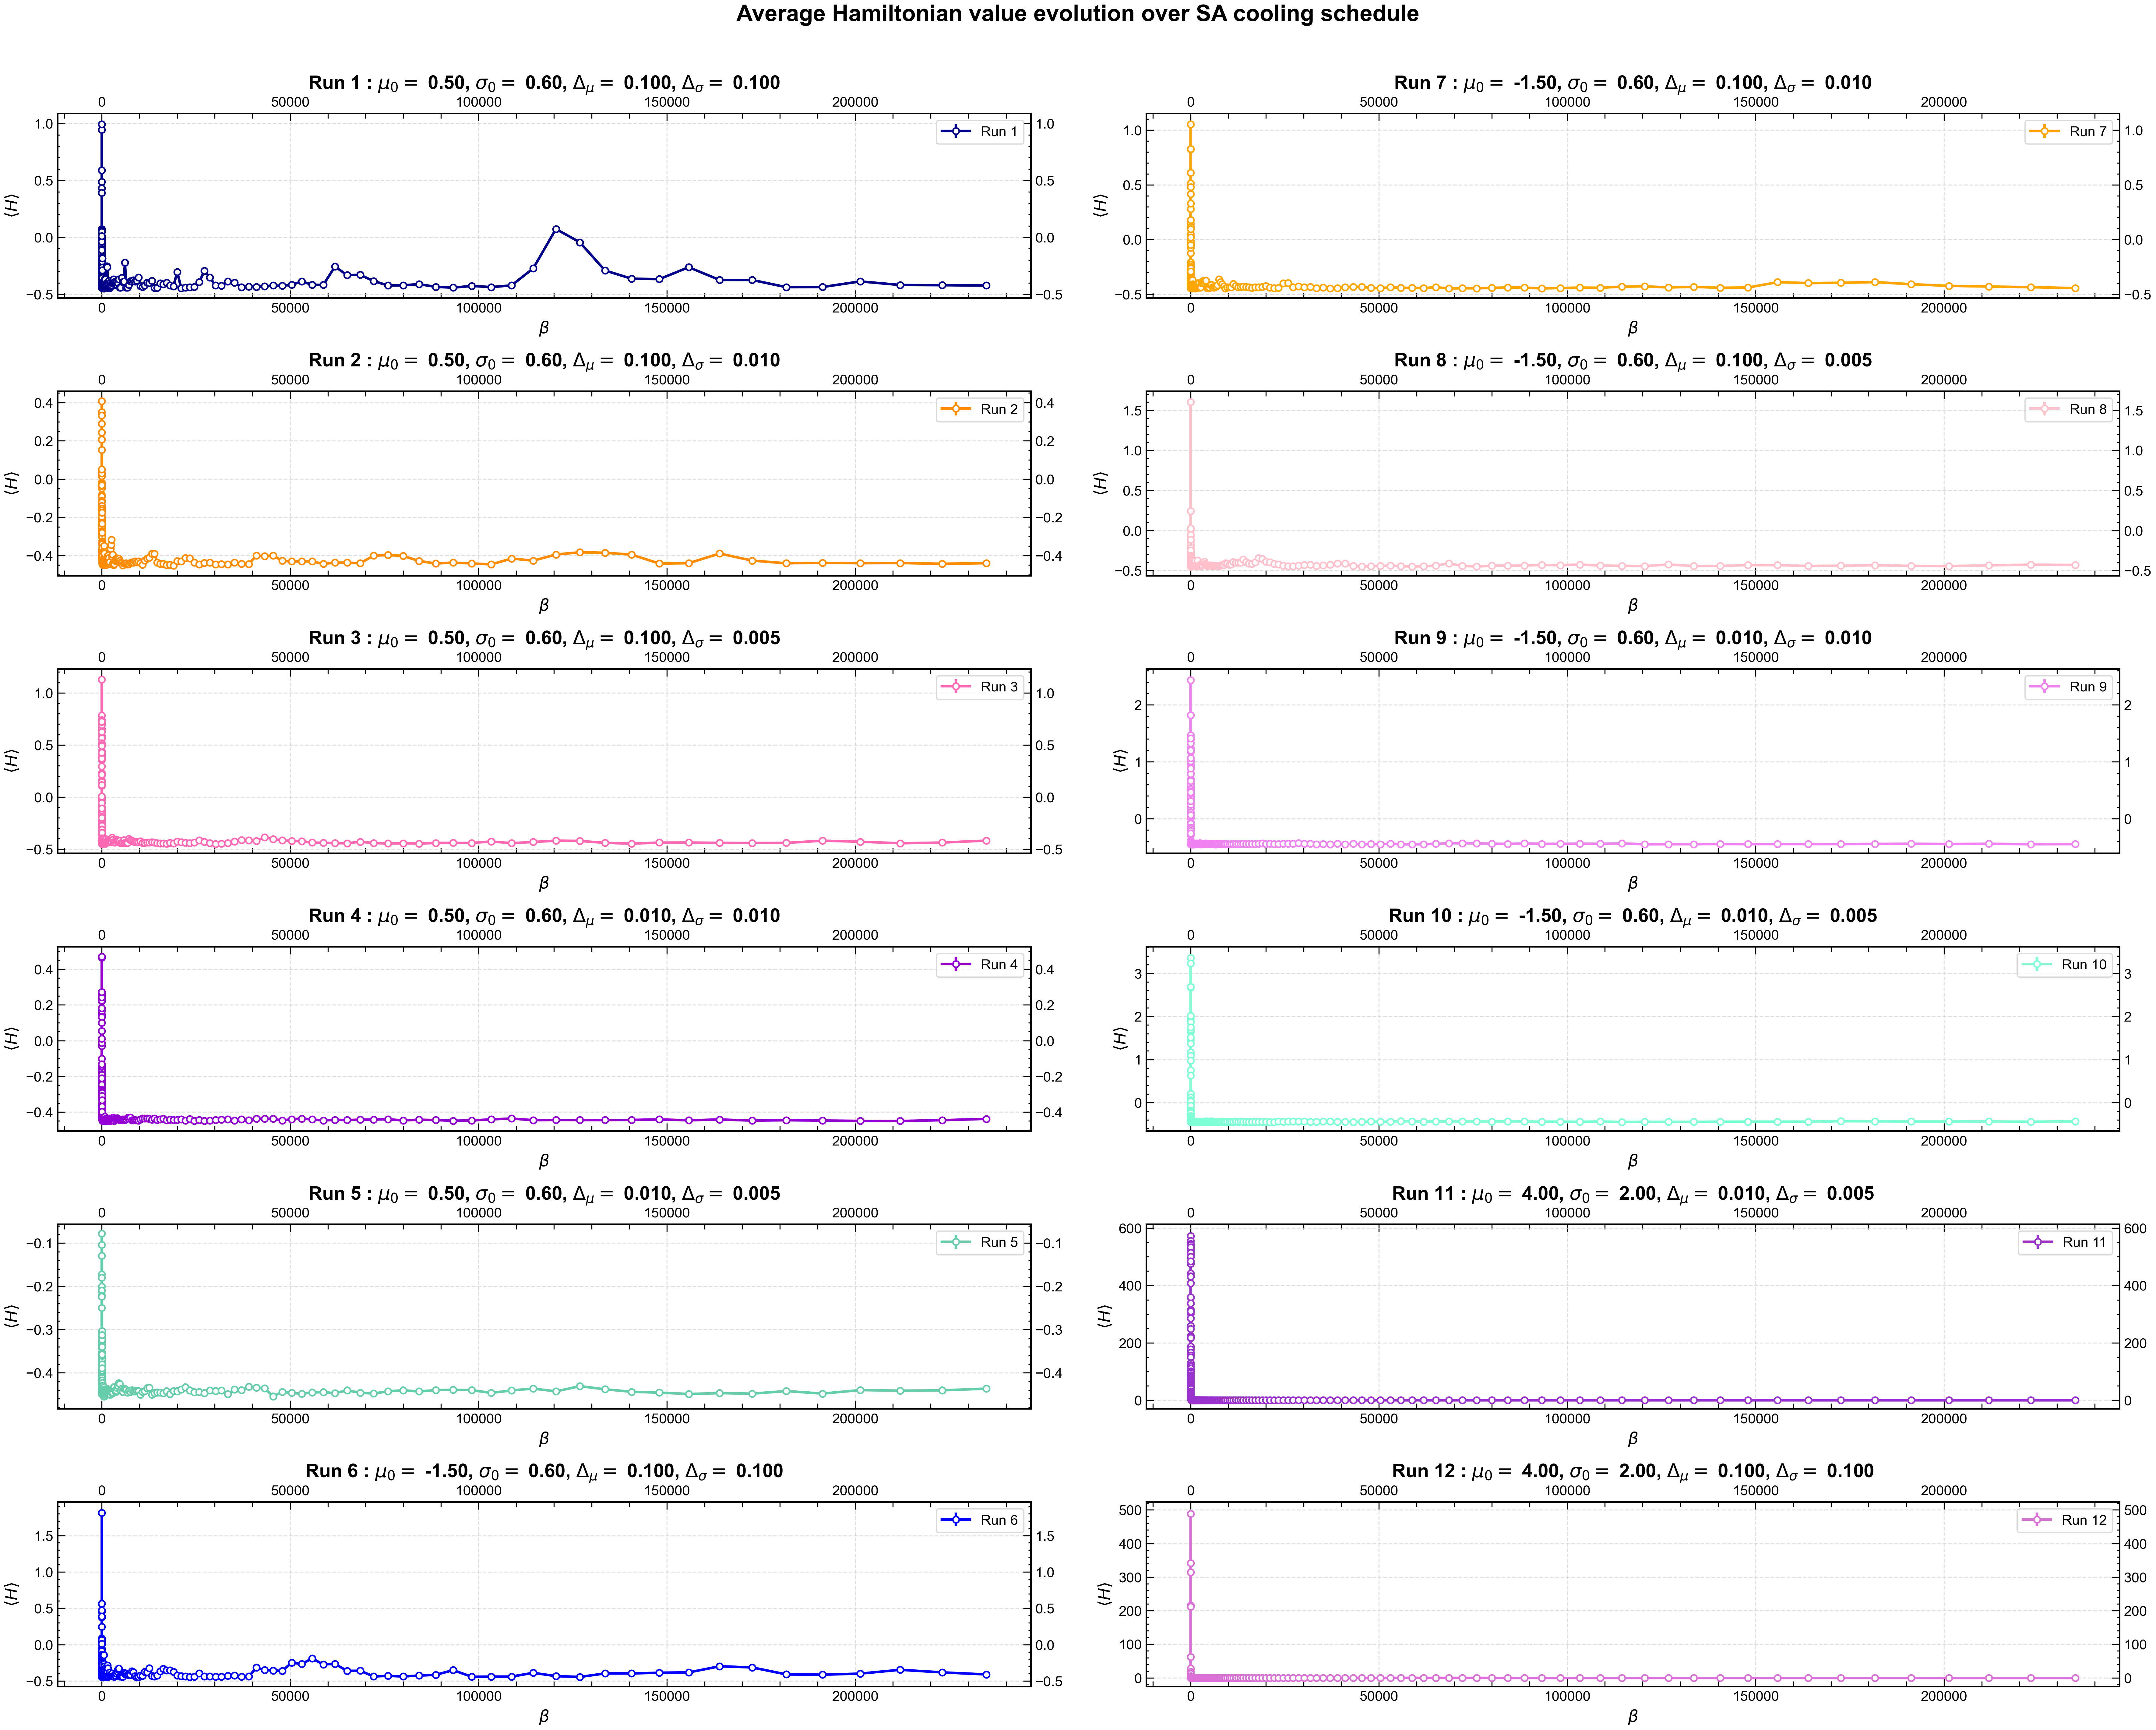

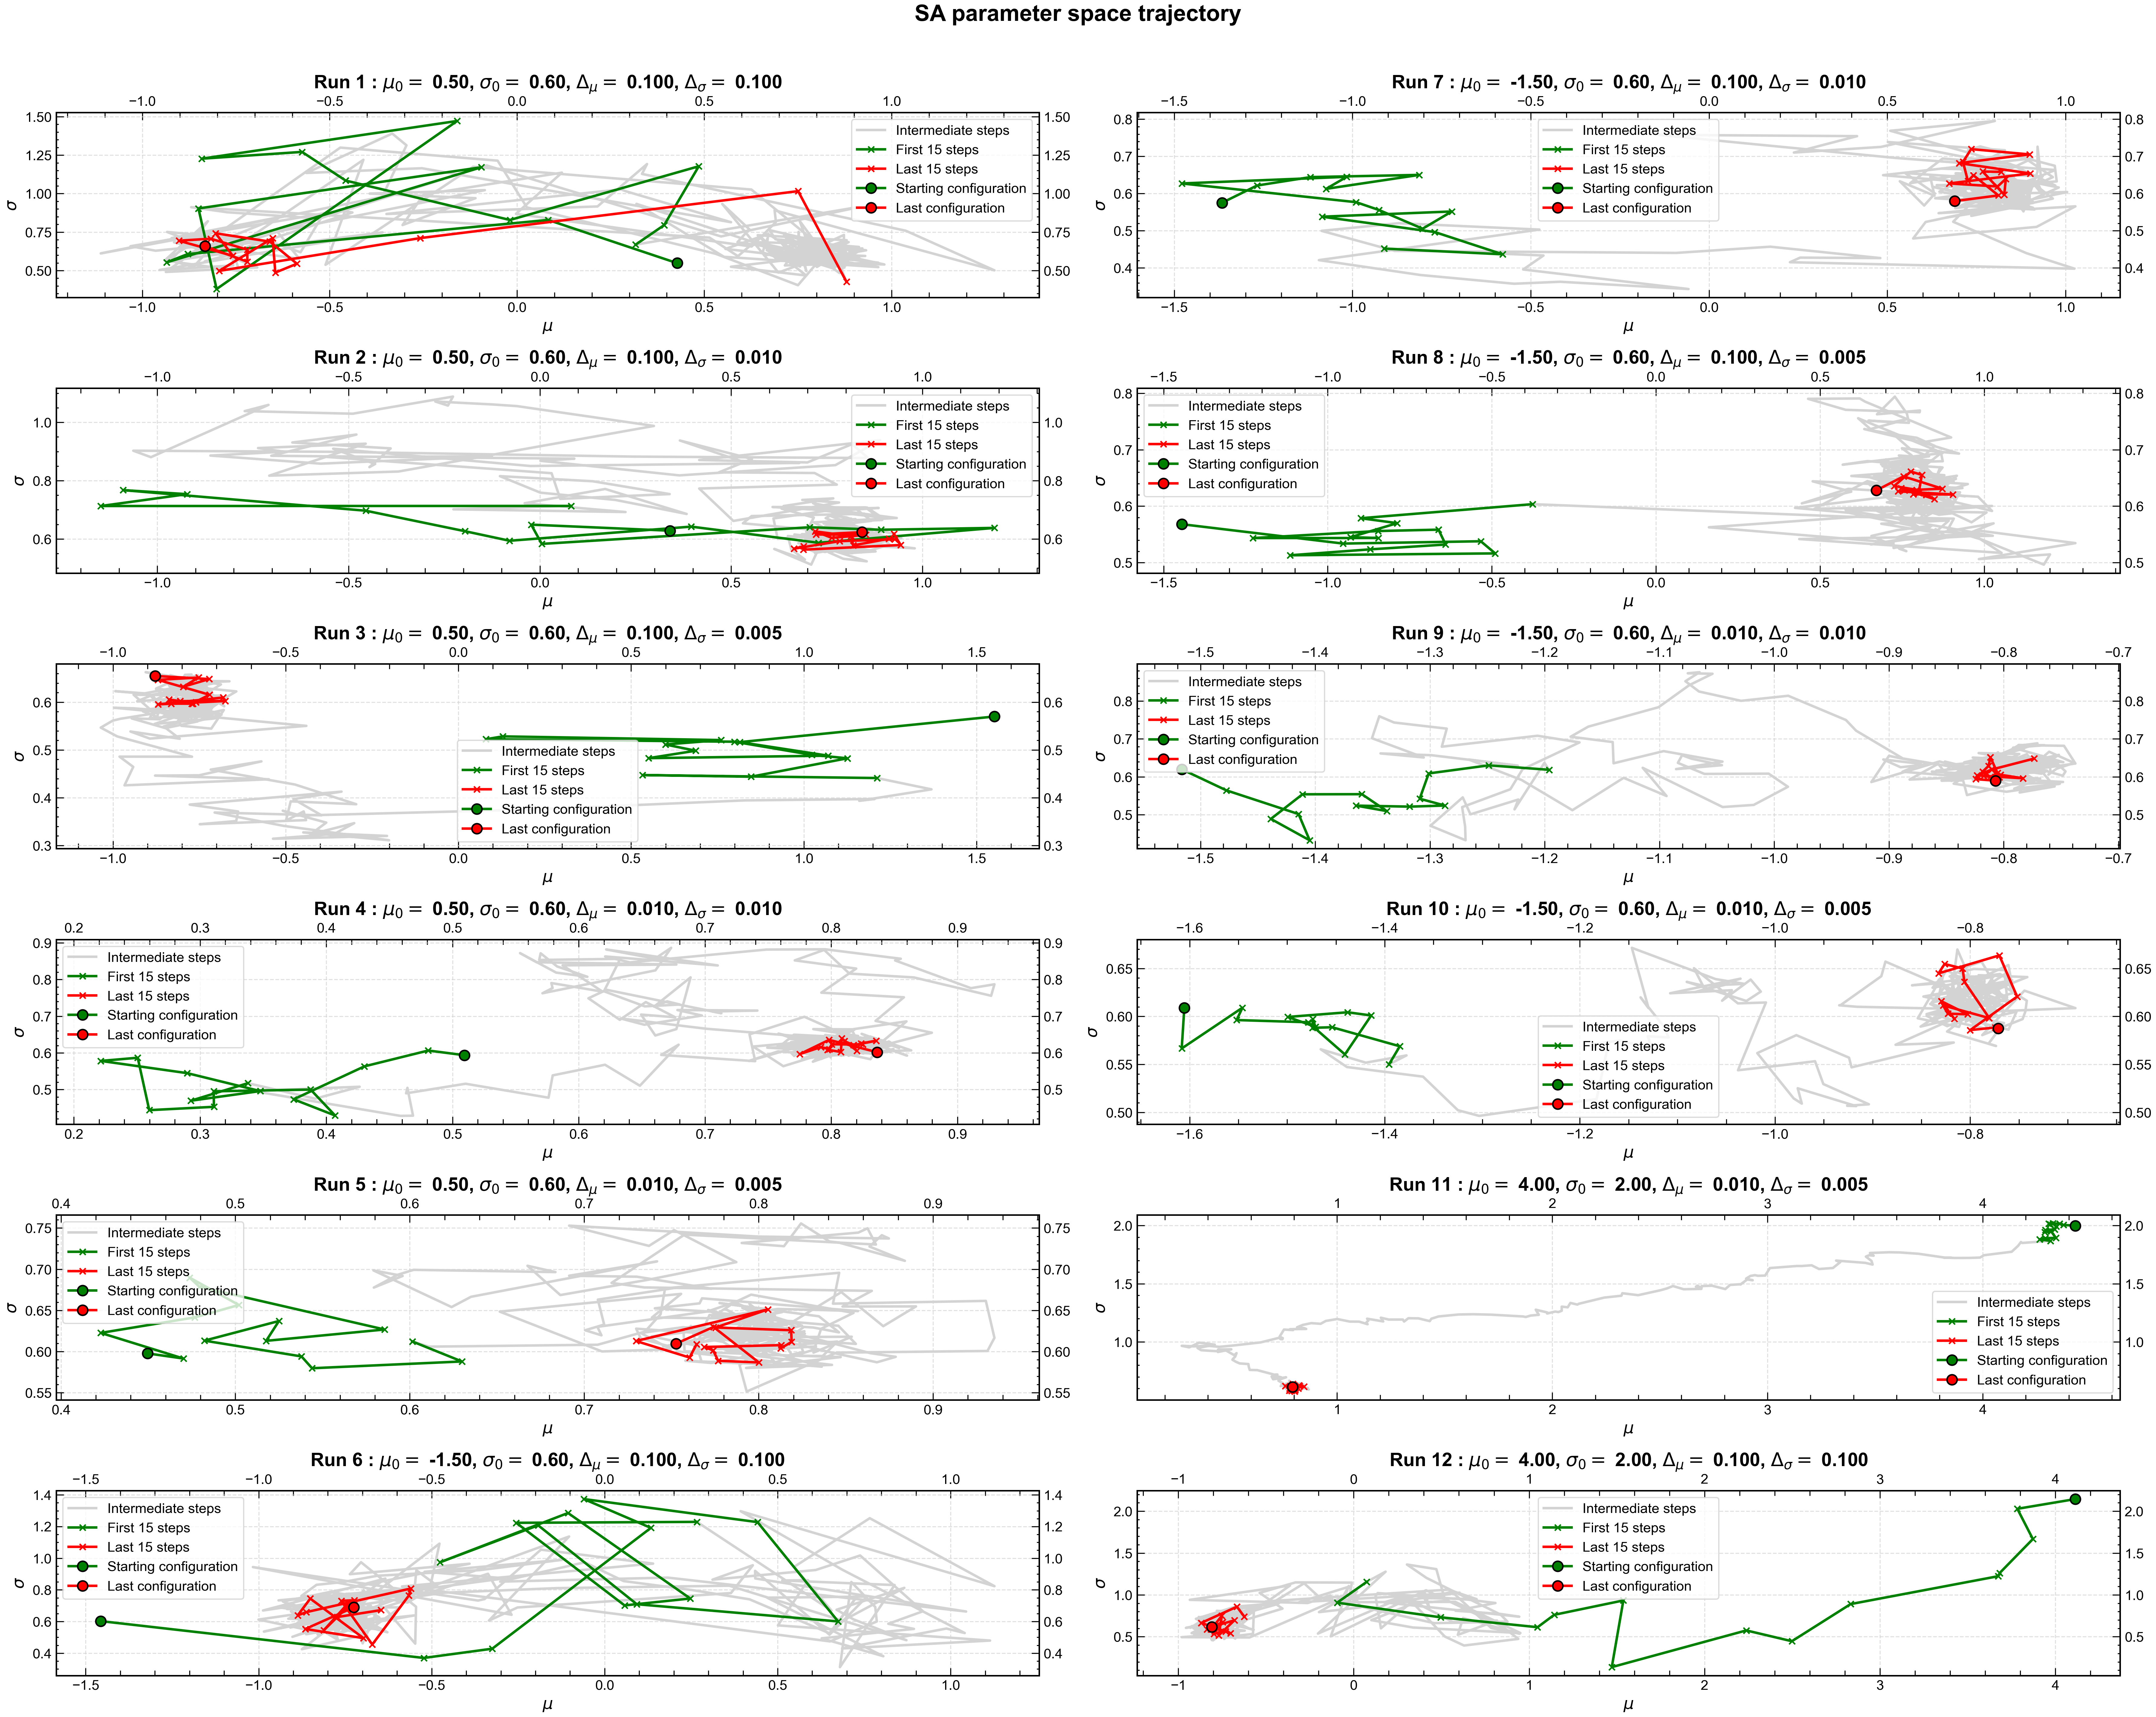

In [7]:
NUM_RUNS = 12 

PAR_0 = [0.5, 0.5, 0.5, 0.5, 0.5, -1.5, -1.5, -1.5, -1.5, -1.5, 4.0, 4.0] 
PAR_1 = [0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 2.0, 2.0]
DPAR_0 = [0.1, 0.1, 0.1, 0.01, 0.01, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.1]
DPAR_1 = [0.1, 0.01, 0.005, 0.01, 0.005, 0.1, 0.01, 0.005, 0.01, 0.005, 0.005, 0.1]

# Colori per una migliore leggibilità
COLORS = ['darkblue', 'darkorange', 'hotpink', 'darkviolet', 'mediumaquamarine', 
          'blue', 'orange', 'pink', 'violet', 'aquamarine', 'darkorchid', 'orchid']

# Liste per contenere tutti gli array NumPy caricati
T = None # T verrà inizializzato con l'array del tempo
MU, SIGMA, H, ERR = [], [], [], []

for k in range(1, NUM_RUNS + 1):
    path = f"runs/run_{k:02d}/OUTPUT/data.dat"
    
    if k == 1:
        t_temp, m, s, h, eh = np.loadtxt(path, usecols=(0, 1, 2, 3, 4), unpack=True)
        T = t_temp
    else:
        m, s, h, eh = np.loadtxt(path, usecols=(1, 2, 3, 4), unpack=True)
    
    MU.append(m)
    SIGMA.append(s)
    H.append(h)
    ERR.append(eh)

BETA = 1 / T


fig, axs = plt.subplots(6, 2, figsize=(24, 20))
plt.suptitle("Average Hamiltonian value evolution over SA cooling schedule", fontsize=18, fontweight='bold')

for i in range(6):
    for j in range(2):
        idx = i + 6 * j # Indice del run (0 a 9)
        axs[i][j].set_title(rf'Run {idx+1} : $\mu_0 = $ {PAR_0[idx]:.2f}, $\sigma_0 = $ {PAR_1[idx]:.2f}, $\Delta_\mu = $ {DPAR_0[idx]:.3f}, $\Delta_\sigma = $ {DPAR_1[idx]:.3f}')
        axs[i][j].errorbar(BETA, H[idx], yerr=ERR[idx], color=COLORS[idx], marker='o', markerfacecolor='white', markeredgecolor=COLORS[idx], markeredgewidth=1.2, markersize=5, linestyle='-', label=f'Run {idx+1}')
        axs[i][j].set_xlabel(r'$\beta$')
        axs[i][j].set_ylabel(r'$\langle H \rangle$')
        axs[i][j].legend(loc='best')
        
fig.tight_layout(rect=[0, 0.03, 1, 0.97])
fig.savefig("plot/SA/sa_energy_evolution.png")

fig, axs = plt.subplots(6, 2, figsize=(24, 20))
plt.suptitle("SA parameter space trajectory", fontsize=18, fontweight='bold')

for i in range(6):
    for j in range(2):
        idx = i + 6 * j # Indice del run (0 a 9)
        axs[i][j].set_title(rf'Run {idx+1} : $\mu_0 = $ {PAR_0[idx]:.2f}, $\sigma_0 = $ {PAR_1[idx]:.2f}, $\Delta_\mu = $ {DPAR_0[idx]:.3f}, $\Delta_\sigma = $ {DPAR_1[idx]:.3f}')
        axs[i][j].plot(MU[idx][14:-14], SIGMA[idx][14:-14], color='lightgray', marker='', markerfacecolor='white', markeredgecolor='lightgray', markeredgewidth=1.2, markersize=5, linestyle='-', label=f'Intermediate steps')
        axs[i][j].plot(MU[idx][:15], SIGMA[idx][:15], color='green', marker='x', markerfacecolor='white', markeredgecolor='green', markeredgewidth=1.2, markersize=5, linestyle='-', label=f'First {15} steps')
        axs[i][j].plot(MU[idx][-15:], SIGMA[idx][-15:], color='red', marker='x', markerfacecolor='white', markeredgecolor='red', markeredgewidth=1.2, markersize=5, linestyle='-', label=f'Last {15} steps')
        axs[i][j].plot(MU[idx][0], SIGMA[idx][0], color='green', marker='o', markerfacecolor='green', markeredgecolor='black', markeredgewidth=1.2, markersize=8, label=f'Starting configuration')
        axs[i][j].plot(MU[idx][-1], SIGMA[idx][-1], color='red', marker='o', markerfacecolor='red', markeredgecolor='black', markeredgewidth=1.2, markersize=8, label=f'Last configuration')
        axs[i][j].set_xlabel(r'$\mu$')
        axs[i][j].set_ylabel(r'$\sigma$')
        axs[i][j].legend(loc='best')

fig.tight_layout(rect=[0, 0.03, 1, 0.97])
fig.savefig("plot/SA/sa_ps_tajectories.png")

minim = [(np.min(h), np.argmin(h)) for h in H]
H_min_values, idx_min = zip(*minim)

print('-------------------------------------------------------------------------------------------------------------------------')
print(' Run | T_min_idx | Beta_min_idx |    H_min | Err_H_min | Mu_min | Sigma_min |')
print('-------------------------------------------------------------------------------------------------------------------------')

for i in range(NUM_RUNS):

    idx = idx_min[i]
    
    print(f'{i+1:4} | {T[idx]:9.6f} | {BETA[idx]:12.1f} | {H_min_values[i]:6.5f} | {ERR[i][idx]:9.5f} | {MU[i][idx]:6.3f} | {SIGMA[i][idx]:9.3f} |')

print('-------------------------------------------------------------------------------------------------------------------------')

<h4>Conclusions</h4>

Analyzing the conducted SA runs reveals a fundamental trade-off related to the **Metropolis perturbation size**:

1. **Large Perturbations** ($\Delta_\mu, \Delta_\sigma$ large):
    - *Benefit*: These steps facilitate greater mobility and **broader exploration** of the parameter space, allowing the algorithm to potentially overcome energy barriers.
    - *Drawback*: They **struggle** during the **intensification** phase at low temperatures, as a larger fraction of the proposed moves are rejected (since they often lead to high-energy states when $T \to 0$).
    - *Observation*: In runs where the initial configuration was close to the optimal values, these large-step simulations tended to find the minimum energy value relatively early in the SA process (at high temperatures).

2. **Small Perturbations** ($\Delta_\mu, \Delta_\sigma$ small):
    - *Benefit*: These steps enable a finer, localized search at low temperatures, allowing the algorithm to **converge closer** to the true GS energy value.
    - *Drawback*: They suffer from **slow convergence** when starting from regions of the parameter space far from the global minimum and also struggle during global exploation, not allowing energy barriers jumps.
    - *Example*: This slow convergence is particularly evident in Simulations **11** and **12** (which share distant initial parameters). The run conducted with smaller steps (Simulation 11) exhibits a visibly slower convergence of the mean energy compared to the run with larger steps (Simulation 12).

A key finding concerns the global exploration capability. We observed that using a large step size, such as $\Delta_\mu = 0.1$, allows the algorithm to cross over into the region of the opposite sign of $\mu$. This aggressive step size facilitates a more exhaustive exploration, potentially discovering deeper minima in disconnected regions of the parameter space. Conversely, reducing this step size, even at high temperatures, prevents such large jumps, severely limiting the algorithm's global exploration capacity.

The general consensus is that a **global search is preferable over a mere local fine search**. While, in this specific example, a prior knowledge allowed us to start the SA near optimal parameters, prioritizing a focused, fine search, the superior approach for a general case is to favor broader exploration.

A possible idea to maximize efficiency would be to adopt an **adaptive step size routine**. This is conceptually similar to the adaptive learning rate used in stochastic gradient descent algorithm (e.g., in ADAM or Adagrad).

In the context of SA, this would involve dynamically modifying the Metropolis perturbation size ($\Delta_\mu, \Delta_\sigma$) as a function of the simulation temperature:
- **High Temperatures**: Use larger perturbations to facilitate wide and rapid exploration of the parameter space.
- **Low Temperatures**: Use smaller, more targeted perturbations to ensure a precise local search and efficient convergence to the minimum.

<a id="h-mean-value"></a>

<h2><span style="color:darkviolet">VMC: Statistical Analysis and Ground State Wave Function</span></h2>

Following the determination of the optimal variational parameters that approximate the GS wave function, the next objective is to perform a statistical study of the progressive mean value of the Hamiltonian ($\langle H \rangle$) and its associated uncertainty as a function of blocks.

This analysis is complemented by sampling the GS wave function ($\Psi_{GS}$) during the VMC simulation. The sampled distribution will be compared against two independent references:

1. The analytical trial wave function $\Psi_T(x)$, normalized and computed using the optimal parameters $\mu^*$ and $\sigma^*$.

2. The numerical solution of the time-independent Schrödinger equation obtained by transforming the differential equation into a matrix eigenvalue problem (details below).

From the preceding Simulated Annealing analysis, the best variational parameters for the ground state were determined as:

$$\mu^* = 0.826 \quad \quad \sigma^* = 0.630.$$

<h4>Implementation</h4>

The sampling of the GS wave function is integrated into the VMC simulation using a new property flag. A boolean flag (`_measure_gs`) is set to true when the property `GS` is read from the input file. The initialization routine sets up the necessary variables for the histogramming process: the number of bins (`_n_bins_gs`), the bin size (`_bin_size_gs`), a normalization constant (`_gs_normalization`), and the starting index for storing the histogram within the measurement vector (`_index_gs`).

```cpp
    void System :: initialize_properties(){
        // ... //
        else if( property == "GS"){
            if(_sim_type != 4){
            cerr << "ERROR: GS wave function sampling is incompatible with ensemble simulations." << endl;
            exit(EXIT_FAILURE);
            }
            ofstream coutgs("../OUTPUT/gs.dat");
            coutgs << "#     BLOCK:         BIN_CENTER:           ACTUAL_V:              V_AVE:              ERROR:" << endl;
            coutgs.close();
            input>>_n_bins_gs;
            _nprop += _n_bins_gs;
            _bin_size_gs = 5.0/_n_bins_gs;
            _gs_normalization = _npart * _bin_size_gs;
            _gs_increment = 1.0/_gs_normalization;
            _measure_gs = true;
            _index_gs = index_property;
            index_property += _n_bins_gs;
        } // ... //
    }
```

The bin size is calculated assuming a maximum sampling range from $-2.5$ to $2.5$. This range is justified because the quantum particle is confined within a double-well potential, and the probability of finding the particle outside this interval is negligibly small due to the strong divergence of the potential.

The sampling is performed by evaluating the walker's position at every VMC step and incrementing the count of the corresponding bin.

```cpp
    void System :: measure(){
        // ... //
        if(_measure_gs){
            double x = _particle(0).getposition(0,true);
            int bin = int((x + 2.5)/_bin_size_gs);
            if(bin >= 0 and bin < _n_bins_gs){
                _measurement(_index_gs + bin) += _gs_increment;
            }
        } // ... //
    }
```

The progressive mean values and uncertainties are calculated following the execution flow of the `averages(int blk)` method and are reported only for the final block of the simulation.

The VMC simulation was conducted using the following input parameters:

<div align="center">

| PARAMETERS | VALUE |
| :--- | :--- |
| SIMULATION_TYPE | 4 |
| RESTART | 0 |
| NPART | 1 |
| DELTA | 2.65 |
| NBLOCKS | 250 |
| NSTEPS | 1000 |
| NPARAM | 2 0.82600 0.62988 |

</div>

<h3>From Time-indipendent Schödinger Equation to Matrix Form</h3>

To obtain a reliable numerical reference for the ground state wave function, we solve the time-independent Schrödinger Equation (TISE) using a **matrix method**.

By discretizing the continuous wave function $\Psi(x)$ over a dense grid of points $x_i$ separated by a distance $dx$, the function can be approximated by a finite vector:

$$\Psi(x) \to \left[ \Psi(x_1), \Psi(x_2), ..., \Psi(x_N) \right] = \left[ \Psi_1, \Psi_2, ..., \Psi_N \right].$$

The TISE, given by the Hamiltonian operator $\hat{H}$:

$$
{\hat H} \Psi(x) = \left( -\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2} + V(x) \right) \Psi(x) = E \Psi(x)
$$

can then be written in matrix form.

The second-order derivative can be approximated using the **finite difference method**. The first derivatives are approximated as:

$$
\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i+1})/2\right) \simeq \frac{\Psi_{i+1}-\Psi_{i}}{dx}\\
\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i-1})/2\right) \simeq \frac{\Psi_{i}-\Psi_{i-1}}{dx}
$$

The second derivative at point $x_i$ is then obtained by discretizing the derivative of the first derivatives:

$$
\frac{\partial^2}{\partial x^2} \Psi(x=x_i) =
\frac{\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i+1})/2\right) - \frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i-1})/2\right)}{dx} =
\frac{\Psi_{i+1}-2\Psi_{i}+\Psi_{i-1}}{dx^2}.
$$

Substituting the finite difference approximation of the second derivative into the TISE yields the **tridiagonal matrix equation**:

$$
\begin{bmatrix}
 \frac{\hbar^2}{m\,dx^2}+V(x_1)& -\frac{\hbar^2}{2m\,dx^2} & 0 & \dots  & 0 \\
-\frac{\hbar^2}{2m\,dx^2} & \frac{\hbar^2}{m\,dx^2}+V(x_2) & -\frac{\hbar^2}{2m\,dx^2} & \dots  & 0 \\
 0                        & -\frac{\hbar^2}{2m\,dx^2} & \frac{\hbar^2}{m\,dx^2}+V(x_3) & \dots  & 0 \\
 \vdots                   & \vdots                    & \vdots & \ddots & \vdots \\
 0                    & 0                & 0 & \dots  & \frac{\hbar^2}{m\,dx^2}+V(x_N)
\end{bmatrix}
\begin{bmatrix}
\Psi_{1} \\
\Psi_{2} \\
\vdots \\
\Psi_{N}
\end{bmatrix}
= E
\begin{bmatrix}
\Psi_{1} \\
\Psi_{2} \\
\vdots \\
\Psi_{N}
\end{bmatrix}.
$$

The problem is reduced to finding the **eigenvalues** ($E$) and **eigenvectors** ($\Psi$) of the resulting Hamiltonian matrix. The lowest eigenvalue corresponds to the Ground State Energy ($E_{GS}$), and the corresponding eigenvector provides the numerical approximation of the Ground State Wave Function ($\Psi_{GS}$).

In [8]:
def gswf(x, mu, sigma):
    a = (x-mu)**2
    b = (x+mu)**2
    c = 1.0/(2.0*sigma*sigma)
    a = a*c
    b = b*c
    d = c/(np.pi)
    return (np.exp(-a) + np.exp(-b))*d*(np.exp(-a) + np.exp(-b))

def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2

hbar = 1
m = 1
a = 10
N = 1000 # number of iterations

block, mean_H, err_H = np.loadtxt("final_run/OUTPUT/hamiltonian.dat", usecols=(0,2,3), unpack=True)
acceptance = np.loadtxt("final_run/OUTPUT/acceptance.dat", usecols=(1))
bin_center, counts, err_counts = np.loadtxt("final_run/OUTPUT/gs.dat", usecols=(1,3,4), unpack=True)


Matrix method H0 = -0.4605
VMC average H0 = -0.4412 ± 0.0019
SA minimum H0 = -0.455 ± 0.009


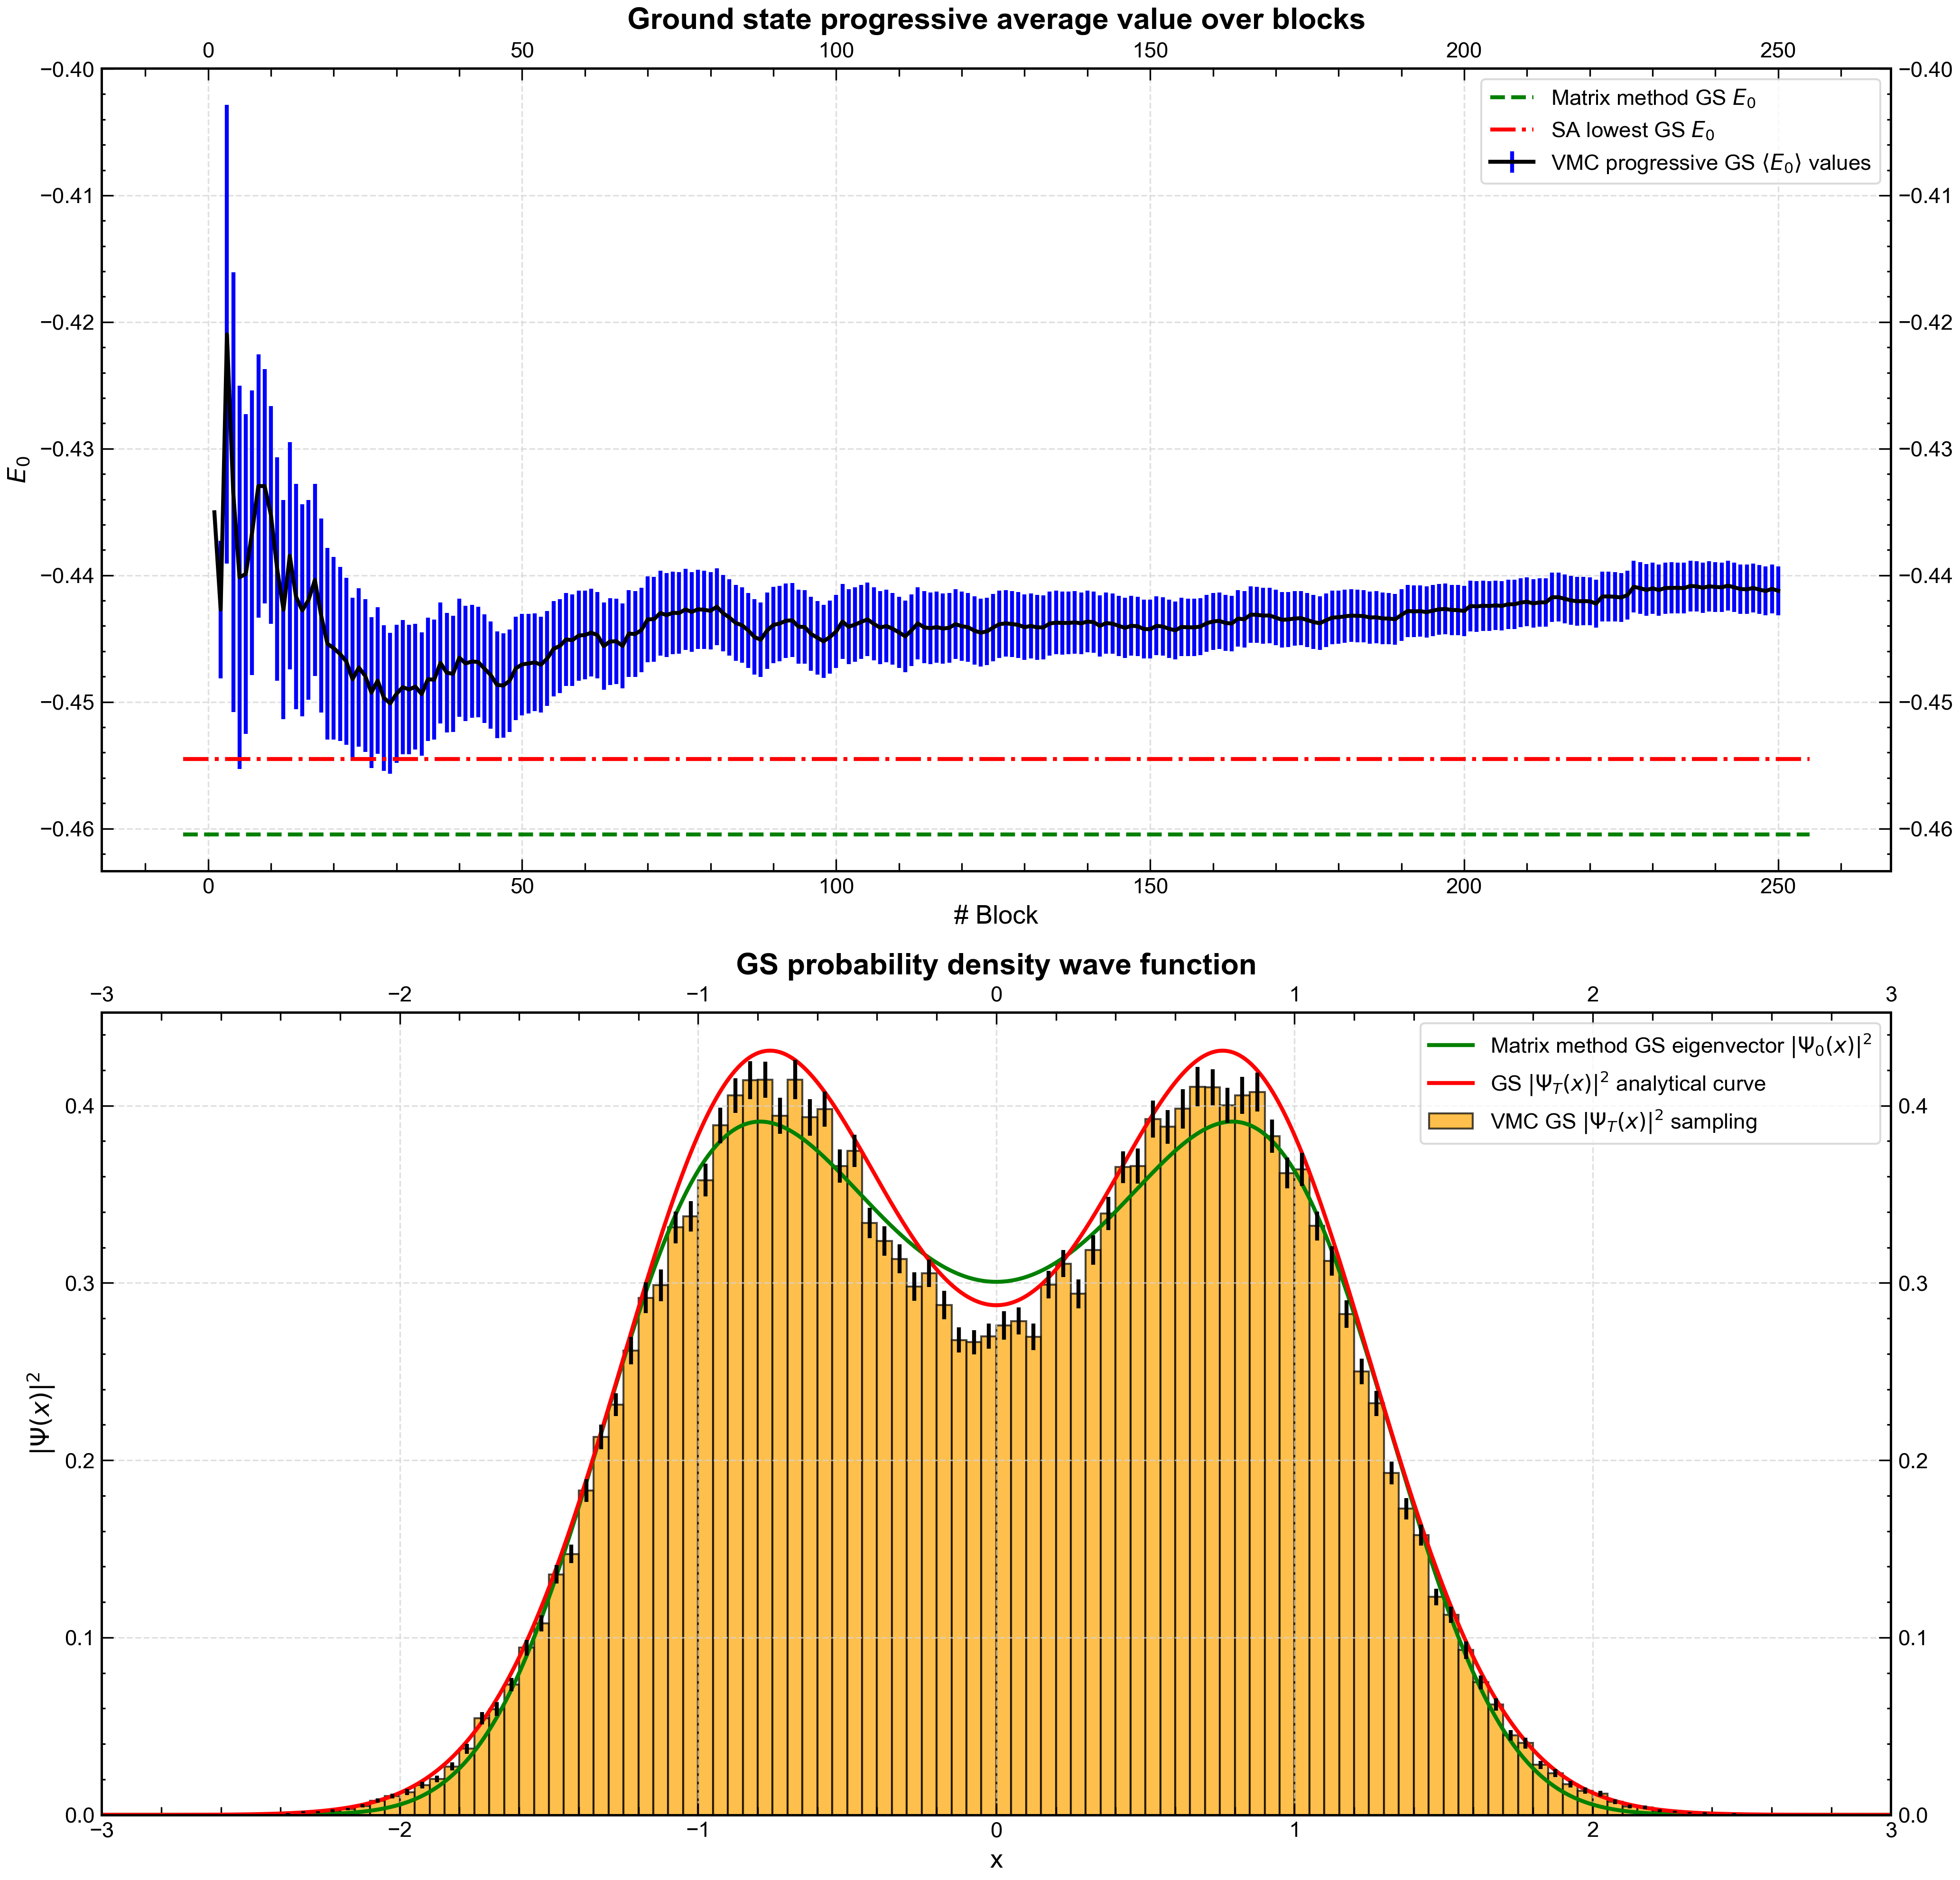

In [9]:
# Step sizes
x = np.linspace(-a/2, a/2, N)
y = gswf(x, 0.82600, 0.62988)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# np.diag(np.array,k) construct a "diagonal" matrix using the np.array
# The default is k=0. Use k>0 for diagonals above the main diagonal, 
# and k<0 for diagonals below the main diagonal

# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

print(f'Matrix method H0 = {E[0]:.4f}')
print(f'VMC average H0 = {mean_H[-1]:.4f} ± {err_H[-1]:.4f}')
print(f'SA minimum H0 = {H_min_values[4]:.3f} ± {0.00901:.3f}')

fig, axs = plt.subplots(2,1,figsize=(14, 14))

axs[0].set_title('Ground state progressive average value over blocks', pad=20)
axs[0].errorbar(block, mean_H, yerr=err_H, color='black', ecolor='blue', label=r'VMC progressive GS $\langle E_0 \rangle$ values')
axs[0].hlines(E[0], block[0]-5, block[-1]+5, linestyle='--', color='green', label=r'Matrix method GS $E_0$')
axs[0].hlines(H_min_values[4], block[0]-5, block[-1]+5, linestyle='-.', color='red', label=r'SA lowest GS $E_0$')
axs[0].set_xlabel('# Block')
axs[0].set_ylabel(r'$E_0$')
axs[0].legend()

axs[1].set_title('GS probability density wave function')
axs[1].plot(x, (psi[0])**2, color='green', linestyle='-', label=r'Matrix method GS eigenvector $|\Psi_0(x)|^2$')
axs[1].plot(x, y, color='red', linestyle='-', label=r'GS $|\Psi_T(x)|^2$ analytical curve')
axs[1].bar(bin_center, counts, width=0.05, yerr = err_counts, ecolor="black", alpha=0.7, color='orange', edgecolor="black", label=r'VMC GS $|\Psi_T(x)|^2$ sampling')
axs[1].set_xlabel('x')
axs[1].set_xlim(-3.0,3.0)
axs[1].set_ylabel(r'$|\Psi(x)|^2$')
axs[1].legend()

fig.tight_layout(rect=[0, 0.03, 1, 0.99])

fig.savefig("plot/GS/gs_analysis.png")
plt.show()

<h4>Conclusions</h4>

Based on the analysis of the graphs, we conclude that <span style="color:green">the variational parameters found during the Simulated Annealing (SA) optimization provide a robust, though approximate, description of the Ground State (GS) for the quantum system under investigation</span>.

The probability density $|\Psi(x)|^2$ sampled via the Variational Monte Carlo (VMC) method shows **excellent agreement** with the numerical solution obtained from the matrix diagonalization of the time-independent Schrödinger equation. This **numerical curve falls within** $1-2\sigma$ **of the VMC sampling** across the entire domain, with minor deviations observed primarily near the origin ($x=0$). This minor discrepancy in the central region can be primarily attributed to finite sampling limitations and the asymptotic nature of Metropolis convergence.

The mean Ground State energy obtained through the VMC simulation is **not statistically compatible** with the energy derived from the numerical matrix solution. Crucially, the VMC estimate ($\langle E_0 \rangle_{VMC}$) is **higher** than the numerical energy ($E_{0,numerical}$), which is **consistent with the variational principle**. This divergence is expected, as VMC provides a variational upper bound to the true GS energy, and the trial wave function used is, by definition, an approximation whose parameters were determined via a stochastic optimization algorithm (SA) subject to its own convergence tolerance.

The overall approach, combining SA for parameter optimization with VMC for expectation value calculation, has proven successful in locating a parameter set that effectively minimizes the Hamiltonian.

The current results suggest two main avenues for future work aimed at reaching a more precise estimate of the true Ground State energy:

1. **Trial Wave Function**: The primary limitation is the variational freedom of the trial function $\Psi_T(\mu, \sigma)$. Improving and/or changing the functional form of $\Psi_T$ to better capture the physics of the double-well potential would theoretically yield a tighter upper bound on $E_{GS}$.

2. **Advanced Optimization**: Further exploration could involve replacing or refining the SA stage. Techniques such as Adaptive Simulated Annealing or a final local optimization step (e.g., using a steepest descent method applied to the VMC gradient of $\langle H \rangle$) could be employed to fine-tune the variational parameters $\mu$ and $\sigma$ to a higher degree of precision before the final VMC calculation run.